# Modular ROSR cases 1-4

Select a case by changing only `CASE_NUMBER` in the final execution cell.
The model structure and plots follow the four original scripts, while repeated
code has been consolidated into reusable functions.

Required parameter corrections requested by the author:
- launch probability = 0.975 for every case;
- base capacity = 30 for Case 1 and 35 for Cases 2-4.

## Optional one-time installation
Run the following in a Jupyter/Colab cell if the packages are not installed:

`%pip install gurobipy scienceplots networkx pandas numpy matplotlib`

A valid Gurobi license is required. In Google Colab, this code can read the
same WLS secrets used in the original notebooks: `secret_WLSACCESSID`,
`secret_WLSSECRET`, and `secret_LICENSEID`.


### Rebalancing-horizon sensitivity

This notebook is identical to `rosr_modular_cases.ipynb` except for the allocation-rebalancing sensitivity. Strategic investment remains restricted to $\theta=4$.

The baseline model places allocation-share bounds at $t=\theta$ and thereafter. The sensitivity **removes the baseline bound at $t=\theta$**, permits scenario-dependent allocations to rebalance freely through a separate horizon $\psi>\theta$, and imposes the long-run share bounds only for $t>\psi$.

- `$\psi=9$`: rebalancing is free through period 9; share bounds apply in periods 10--14.
- `$\psi=14=\nu$`: rebalancing is unrestricted throughout the valuation horizon; no allocation-share bounds are imposed.

Use `rebalancing_horizon=None` to reproduce the baseline model exactly. A numerical value `$\psi$` is a relaxation of the baseline, not an alternative parameterization that reproduces it at `$\psi=\theta$`.

This fixed notebook runs the `$\psi=9$` sensitivity.


In [1]:
from __future__ import annotations

import itertools
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Mapping, Optional, Sequence, Tuple

import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import networkx as nx
import numpy as np
import pandas as pd

try:
    import scienceplots  # noqa: F401  # Registers the "science" style.
except ImportError:
    scienceplots = None

## 1. Case definitions and runtime controls

In [2]:
@dataclass(frozen=True)
class CaseConfig:
    """Inputs that distinguish Cases 1-4."""

    case_number: int
    established_products: int
    launch_products: int
    compete_products: int
    availability_floor: float
    base_capacity: float
    disruption_probability: float

    # Requested probabilities are fixed consistently across all four cases.
    launch_probability: float = 0.975


@dataclass(frozen=True)
class RuntimeConfig:
    """Solver, scenario, plotting, and reproducibility controls."""

    planning_exhaustive: bool = False
    planning_sample_size: int = 40
    planning_scenario_seed: int = 0
    capacity_seed: int = 73

    # The original evaluation code uses all 3^4 Increase/Flat/Decrease tuples.
    evaluation_exhaustive: bool = True
    evaluation_sample_size: int = 81
    evaluation_seed: int = 0

    # Keep False to reproduce the original evaluation set. Set True to include
    # the NoLaunch state in out-of-sample evaluation for launch products.
    evaluation_include_no_launch: bool = False

    # Optional rebalancing-horizon sensitivity.
    # None reproduces the baseline rosr_modular_cases model exactly: the
    # allocation-share bounds apply at theta and in every later valuation period.
    # For a sensitivity value psi > theta, allocations are free through psi and
    # the stable share bounds apply only for t > psi. Setting psi = nu therefore
    # removes the allocation-share bounds throughout the valuation horizon.
    rebalancing_horizon: Optional[int] = None

    planning_time_limit: Optional[float] = 300.0
    start_period_time_limit: Optional[float] = 180.0
    evaluation_time_limit: Optional[float] = 60.0
    perfect_information_time_limit: Optional[float] = 120.0

    output_flag: int = 1
    evaluation_output_flag: int = 0
    threads: int = 8

    run_decision_rule: bool = True
    run_perfect_information: bool = True
    make_plots: bool = True
    save_plots: bool = True
    use_latex_plot_style: bool = False


CASE_CONFIGS: Dict[int, CaseConfig] = {
    # Case 1: four established products, deterministic availability floor,
    # requested base capacity of 30.
    1: CaseConfig(
        case_number=1,
        established_products=4,
        launch_products=0,
        compete_products=0,
        availability_floor=1.0,
        base_capacity=30.0,
        disruption_probability=0,
    ),
    # Case 2: same product mix as Case 1, with availability uncertainty and 5% disruption probability.
    2: CaseConfig(
        case_number=2,
        established_products=4,
        launch_products=0,
        compete_products=0,
        availability_floor=0.8,
        base_capacity=35.0,
        disruption_probability=0.05,
    ),
    # Case 3: two established, one competed, and one launch product.
    3: CaseConfig(
        case_number=3,
        established_products=2,
        launch_products=1,
        compete_products=1,
        availability_floor=1.0,
        base_capacity=35.0,
        disruption_probability=0,
    ),
    # Case 4: same product mix as Case 3, with availability uncertainty and 5% disruption probability.
    4: CaseConfig(
        case_number=4,
        established_products=2,
        launch_products=1,
        compete_products=1,
        availability_floor=0.8, 
        base_capacity=35.0,
        disruption_probability=0.05,
    ),
}


def get_case_config(case_number: int) -> CaseConfig:
    """Return one validated case configuration."""

    if case_number not in CASE_CONFIGS:
        raise ValueError(f"CASE_NUMBER must be one of {sorted(CASE_CONFIGS)}.")
    return CASE_CONFIGS[case_number]

## 2. Core data containers

In [3]:
@dataclass
class ProblemData:
    """Deterministic sets, costs, demand parameters, and initial design data."""

    config: CaseConfig

    # Horizons and index sets.
    theta: int
    nu: int
    T_I: List[int]
    T_V: List[int]

    # Machine and product sets.
    M: List[str]
    E: List[str]
    C: List[str]
    L: List[str]
    P: List[str]
    product_type: Dict[str, str]

    # Demand states and trajectories before joint-scenario construction.
    base_states: List[str]
    launch_states: List[str]
    base_demand: Dict[Tuple[str, str, int], float]

    # Economic parameters.
    discount_rate: float
    unit_profit: Dict[Tuple[str, str], float]
    fixed_opex: Dict[str, float]
    machine_capex: Dict[str, float]
    arc_capex: Dict[Tuple[str, str], float]
    lifetime: Dict[str, int]

    # Installed system at the start of the horizon.
    pre_installed_machines: List[str]
    pre_installed_arcs: List[Tuple[str, str]]


@dataclass
class ScenarioSet:
    """A complete stochastic scenario set used by an optimization/evaluation."""

    scenario_ids: List[int]
    scenario_map: Dict[int, Tuple[str, ...]]
    probabilities: Dict[int, float]
    demand: Dict[Tuple[str, int, int], float]
    capacity: Dict[Tuple[str, int, int], float]


@dataclass
class MultiPeriodDesign:
    """Solved multi-period first-stage design."""

    objective_value: float
    machine_on: Dict[Tuple[str, int], float]
    machine_start: Dict[Tuple[str, int], float]
    arc_on: Dict[Tuple[str, str, int], float]
    production: Dict[Tuple[str, str, int, int], float]


@dataclass
class StartPeriodDesign:
    """Solved design in which all investments occur in period zero."""

    objective_value: float
    machine_on: Dict[str, float]
    machine_start: Dict[str, float]
    arc_on: Dict[Tuple[str, str], float]


@dataclass
class PolicyNPVs:
    """Per-scenario NPV arrays for all policies in the comparison."""

    multi_period: List[float]
    start_period: List[float]
    long_chain: List[float]
    decision_rule: List[float]
    perfect_information: List[float]

## 3. Gurobi and plotting setup

In [4]:
def read_colab_wls_options() -> Dict[str, object]:
    """Read optional Gurobi WLS credentials from Google Colab secrets.

    When the code is run locally, an empty dictionary is returned and Gurobi
    uses the local license configuration instead.
    """

    try:
        from google.colab import userdata  # type: ignore
    except ImportError:
        return {}

    access_id = userdata.get("secret_WLSACCESSID")
    secret = userdata.get("secret_WLSSECRET")
    license_id = userdata.get("secret_LICENSEID")

    if not (access_id and secret and license_id):
        return {}

    return {
        "WLSACCESSID": access_id,
        "WLSSECRET": secret,
        "LICENSEID": int(license_id),
    }


def create_gurobi_environment(output_dir: Path) -> gp.Env:
    """Create one reusable Gurobi environment for a complete case run."""

    output_dir.mkdir(parents=True, exist_ok=True)
    log_path = output_dir / "gurobi.log"
    options = read_colab_wls_options()

    if options:
        return gp.Env(str(log_path), params=options)
    return gp.Env(str(log_path))


def configure_model(
    model: gp.Model,
    *,
    output_flag: int,
    threads: int,
    time_limit: Optional[float],
) -> None:
    """Apply solver controls consistently to every Gurobi model."""

    model.Params.OutputFlag = output_flag
    model.Params.Threads = threads
    if time_limit is not None:
        model.Params.TimeLimit = time_limit


def optimize_and_check(model: gp.Model) -> float:
    """Optimize a model and return its objective after validating a solution."""

    model.optimize()

    if model.SolCount <= 0:
        raise RuntimeError(
            f"Model {model.ModelName!r} produced no feasible solution; "
            f"Gurobi status={model.Status}."
        )

    return float(model.ObjVal)


def setup_plot_style(use_latex: bool = False) -> None:
    """Use the original SciencePlots look, with a robust no-LaTeX default."""

    if scienceplots is None:
        plt.style.use("default")
        return

    style = ["science"] if use_latex else ["science", "no-latex"]
    plt.style.use(style)

## 4. Build deterministic case data and demand trajectories

In [5]:
def states_for_product(data: ProblemData, product: str) -> List[str]:
    """Return the valid demand states for one product."""

    if data.product_type[product] == "L":
        return data.launch_states
    return data.base_states


def build_problem_data(config: CaseConfig) -> ProblemData:
    """Construct all deterministic data shared by planning and evaluation."""

    # Planning and valuation horizons from the original code.
    theta = 4
    nu = 14
    T_I = list(range(theta + 1))
    T_V = list(range(nu + 1))

    # Product counts and timing parameters.
    launch_time = 3
    competition_time = 3
    launch_ramp_time = 1
    decline_ramp_time = 1

    # Demand levels and state-dependent slopes.
    base_level = 30.0
    growth_level = 45.0
    decline_level = 15.0
    base_slope = 1.0
    growth_slope = 2.0
    decline_slope = 1.0

    # Eight resources are used in every original case.
    M = [f"Resource {idx + 1}" for idx in range(8)]
    E = [f"Product E{idx + 1}" for idx in range(config.established_products)]
    C = [f"Product C{idx + 1}" for idx in range(config.compete_products)]
    L = [f"Product L{idx + 1}" for idx in range(config.launch_products)]
    P = E + C + L

    product_type = {
        product: ("E" if product in E else "L" if product in L else "C")
        for product in P
    }

    base_states = ["Increase", "Flat", "Decrease"]
    launch_states = ["Increase", "Flat", "Decrease", "NoLaunch"]

    # State slopes follow the original scripts.
    base_slopes = {
        "Increase": +base_slope,
        "Flat": 0.0,
        "Decrease": -base_slope,
    }
    growth_slopes = {
        "Increase": +growth_slope,
        "Flat": 0.0,
        "Decrease": -growth_slope,
    }
    decline_slopes = {
        "Increase": +decline_slope,
        "Flat": 0.0,
        "Decrease": -decline_slope,
    }

    # Build d_bar[j,state,t], the trajectory before products are combined into
    # joint scenarios.
    base_demand: Dict[Tuple[str, str, int], float] = {}

    for product in P:
        valid_states = launch_states if product_type[product] == "L" else base_states

        for state in valid_states:
            for t in T_V:
                if product_type[product] == "E":
                    demand_value = base_level + base_slopes[state] * t

                elif product_type[product] == "L":
                    if state == "NoLaunch":
                        demand_value = 0.0
                    elif t < launch_time:
                        demand_value = 0.0
                    elif t < launch_time + launch_ramp_time:
                        demand_value = (
                            growth_level
                            / launch_ramp_time
                            * (t - launch_time + 1)
                        )
                    else:
                        demand_value = (
                            growth_level
                            + growth_slopes[state]
                            * (t - launch_time - launch_ramp_time + 1)
                        )

                else:  # Competed/declining product.
                    if t < competition_time:
                        demand_value = base_level
                    elif t < competition_time + decline_ramp_time:
                        demand_value = (
                            base_level
                            - (base_level - decline_level)
                            / decline_ramp_time
                            * (t - competition_time + 1)
                        )
                    else:
                        demand_value = (
                            decline_level
                            + decline_slopes[state]
                            * (t - competition_time - decline_ramp_time + 1)
                        )

                # Demand cannot become negative.
                base_demand[product, state, t] = max(0.0, demand_value)

    # Core economics from the original notebooks.
    discount_rate = 0.075
    unit_profit = {(i, j): 300.0 for i in M for j in P}
    fixed_opex = {i: 1_000.0 for i in M}
    machine_capex = {i: 25_000.0 for i in M}
    arc_capex = {(i, j): 1_000.0 for i in M for j in P}
    lifetime = {i: 10 for i in M}

    # Established and competed products begin with one paired resource each.
    pre_installed_machines = M[: len(E) + len(C)]
    pre_installed_arcs = list(zip(pre_installed_machines, E + C))

    # Pre-installed resources and arcs have zero start-up CAPEX, exactly as in
    # the original scripts.
    for machine in pre_installed_machines:
        machine_capex[machine] = 0.0
    for arc in pre_installed_arcs:
        arc_capex[arc] = 0.0

    return ProblemData(
        config=config,
        theta=theta,
        nu=nu,
        T_I=T_I,
        T_V=T_V,
        M=M,
        E=E,
        C=C,
        L=L,
        P=P,
        product_type=product_type,
        base_states=base_states,
        launch_states=launch_states,
        base_demand=base_demand,
        discount_rate=discount_rate,
        unit_profit=unit_profit,
        fixed_opex=fixed_opex,
        machine_capex=machine_capex,
        arc_capex=arc_capex,
        lifetime=lifetime,
        pre_installed_machines=pre_installed_machines,
        pre_installed_arcs=pre_installed_arcs,
    )


def discount_factor(data: ProblemData, t: int) -> float:
    """Present-value factor used by the original model for period t."""

    return 1.0 / (1.0 + data.discount_rate) ** (t + 1)

def share_bound_periods(
    data: ProblemData,
    runtime: RuntimeConfig,
) -> List[int]:
    """Return valuation periods in which long-run allocation-share bounds apply.

    Baseline (``rebalancing_horizon is None``)
        Reproduce ``rosr_modular_cases.ipynb`` exactly: share bounds apply at
        theta and throughout the remaining valuation horizon.

    Sensitivity (``psi = rebalancing_horizon > theta``)
        Remove the baseline bound at theta, allow scenario-dependent allocations
        to rebalance freely through psi, and impose stable share bounds only for
        periods t > psi. Thus psi=9 gives bounds in periods 10,...,14, while
        psi=nu=14 gives no share-bound periods.
    """

    psi = runtime.rebalancing_horizon
    if psi is None:
        return [t for t in data.T_V if t >= data.theta]

    psi = int(psi)
    if psi <= data.theta:
        raise ValueError(
            "For the rebalancing sensitivity, psi must satisfy theta < psi <= nu. "
            "Use rebalancing_horizon=None to reproduce the baseline model."
        )
    if psi > data.nu:
        raise ValueError(
            f"rebalancing_horizon (psi={psi}) cannot exceed nu={data.nu}."
        )

    return [t for t in data.T_V if t > psi]


## 5. Scenario generation

In [6]:
def product_state_probabilities(
    data: ProblemData,
    *,
    include_no_launch: bool,
) -> Tuple[List[List[str]], List[List[float]]]:
    """Return each product's state space and state probabilities."""

    all_states: List[List[str]] = []
    all_probabilities: List[List[float]] = []

    for product in data.P:
        if data.product_type[product] == "L" and include_no_launch:
            all_states.append(list(data.launch_states))
            all_probabilities.append(
                [
                    data.config.launch_probability / 3.0,
                    data.config.launch_probability / 3.0,
                    data.config.launch_probability / 3.0,
                    1.0 - data.config.launch_probability,
                ]
            )
        else:
            all_states.append(list(data.base_states))
            all_probabilities.append([1.0 / 3.0] * 3)

    return all_states, all_probabilities


def build_joint_scenarios(
    data: ProblemData,
    *,
    include_no_launch: bool,
    exhaustive: bool,
    sample_size: int,
    random_seed: int,
    weighted_sampling: bool,
) -> Tuple[List[int], Dict[int, Tuple[str, ...]], Dict[int, float]]:
    """Build a joint scenario map and normalized scenario probabilities."""

    per_product_states, per_product_probabilities = product_state_probabilities(
        data,
        include_no_launch=include_no_launch,
    )

    all_tuples = list(itertools.product(*per_product_states))
    weights = np.empty(len(all_tuples), dtype=float)

    for tuple_index, state_tuple in enumerate(all_tuples):
        joint_weight = 1.0
        for product_index, state in enumerate(state_tuple):
            state_space = per_product_states[product_index]
            state_probabilities = per_product_probabilities[product_index]
            joint_weight *= state_probabilities[state_space.index(state)]
        weights[tuple_index] = joint_weight

    positive_indices = np.flatnonzero(weights > 0.0)
    if len(positive_indices) == 0:
        raise ValueError("All scenario weights are zero.")

    if exhaustive:
        kept_indices = positive_indices
    else:
        number_to_keep = min(sample_size, len(positive_indices))
        rng = np.random.default_rng(random_seed)

        if weighted_sampling:
            probabilities = weights / weights.sum()
        else:
            probabilities = None

        kept_indices = rng.choice(
            len(all_tuples),
            size=number_to_keep,
            replace=False,
            p=probabilities,
        )

    scenario_map = {
        new_id: all_tuples[old_id]
        for new_id, old_id in enumerate(kept_indices)
    }
    scenario_ids = list(scenario_map)

    kept_weights = weights[np.asarray(kept_indices, dtype=int)]
    kept_weights = kept_weights / kept_weights.sum()
    scenario_probabilities = {
        scenario_id: float(kept_weights[position])
        for position, scenario_id in enumerate(scenario_ids)
    }

    return scenario_ids, scenario_map, scenario_probabilities


def build_scenario_demand(
    data: ProblemData,
    scenario_map: Mapping[int, Tuple[str, ...]],
) -> Dict[Tuple[str, int, int], float]:
    """Expand product-state trajectories into joint-scenario demand."""

    demand: Dict[Tuple[str, int, int], float] = {}

    for scenario_id, state_tuple in scenario_map.items():
        for product_index, product in enumerate(data.P):
            state = state_tuple[product_index]
            for t in data.T_V:
                demand[product, scenario_id, t] = data.base_demand[product, state, t]

    return demand


def build_scenario_capacity(
    data: ProblemData,
    scenario_ids: Sequence[int],
    capacity_rng: random.Random,
) -> Dict[Tuple[str, int, int], float]:
    """Generate capacity using the original disruption/availability process."""

    capacity: Dict[Tuple[str, int, int], float] = {}

    for machine in data.M:
        for scenario_id in scenario_ids:
            for t in data.T_V:
                disrupted = (
                    capacity_rng.random()
                    < data.config.disruption_probability
                )

                if disrupted:
                    capacity[machine, scenario_id, t] = 0.0
                else:
                    availability = capacity_rng.uniform(
                        data.config.availability_floor,
                        1.0,
                    )
                    capacity[machine, scenario_id, t] = (
                        data.config.base_capacity * availability
                    )

    return capacity


def build_planning_scenarios(
    data: ProblemData,
    runtime: RuntimeConfig,
    capacity_rng: random.Random,
) -> ScenarioSet:
    """Create the probability-weighted scenario set used to choose designs."""

    scenario_ids, scenario_map, probabilities = build_joint_scenarios(
        data,
        include_no_launch=True,
        exhaustive=runtime.planning_exhaustive,
        sample_size=runtime.planning_sample_size,
        random_seed=runtime.planning_scenario_seed,
        weighted_sampling=True,
    )

    demand = build_scenario_demand(data, scenario_map)
    capacity = build_scenario_capacity(data, scenario_ids, capacity_rng)

    return ScenarioSet(
        scenario_ids=scenario_ids,
        scenario_map=scenario_map,
        probabilities=probabilities,
        demand=demand,
        capacity=capacity,
    )


def build_evaluation_scenarios(
    data: ProblemData,
    runtime: RuntimeConfig,
    capacity_rng: random.Random,
) -> ScenarioSet:
    """Create the scenario set used for CDF and policy comparisons.

    By default this reproduces the original evaluation logic: all products use
    Increase/Flat/Decrease states, so there are 3^4 = 81 equally weighted
    scenarios. `evaluation_include_no_launch=True` can be used for a fully
    probability-consistent launch evaluation.
    """

    scenario_ids, scenario_map, probabilities = build_joint_scenarios(
        data,
        include_no_launch=runtime.evaluation_include_no_launch,
        exhaustive=runtime.evaluation_exhaustive,
        sample_size=runtime.evaluation_sample_size,
        random_seed=runtime.evaluation_seed,
        weighted_sampling=runtime.evaluation_include_no_launch,
    )

    # Preserve the original uniform evaluation weighting when NoLaunch is not
    # included. This makes the CDF an empirical distribution over the 81 states.
    if not runtime.evaluation_include_no_launch:
        probabilities = {
            scenario_id: 1.0 / len(scenario_ids)
            for scenario_id in scenario_ids
        }

    demand = build_scenario_demand(data, scenario_map)
    capacity = build_scenario_capacity(data, scenario_ids, capacity_rng)

    return ScenarioSet(
        scenario_ids=scenario_ids,
        scenario_map=scenario_map,
        probabilities=probabilities,
        demand=demand,
        capacity=capacity,
    )

## 6. Plotting helpers that reproduce the original figures

In [7]:
OKABE_ITO = [
    "#009E73",
    "#0072B2",
    "#E69F00",
    "#D55E00",
    "#0072B2",
    "#D55E00",
    "#CC79A7",
    "#000000",
]


def _save_or_show(
    figure: plt.Figure,
    output_path: Optional[Path],
    *,
    save_plots: bool,
) -> None:
    """Save and display one plot without duplicating boilerplate."""

    if save_plots and output_path is not None:
        figure.savefig(output_path, bbox_inches="tight")
    plt.show()


def plot_bipartite_graph(
    data: ProblemData,
    arcs: Iterable[Tuple[str, str]],
    *,
    title: str,
    output_path: Optional[Path],
    save_plots: bool,
) -> None:
    """Draw the same parallel bipartite layout used in the original scripts."""

    graph = nx.Graph()
    graph.add_nodes_from(data.M, bipartite=0)
    graph.add_nodes_from(data.P, bipartite=1)
    graph.add_edges_from(arcs)

    positions: Dict[str, Tuple[float, float]] = {}
    for index, node in enumerate(data.M):
        positions[node] = (0.0, float(len(data.M) - index - 1))
    for index, node in enumerate(data.P):
        positions[node] = (1.0, float(len(data.M) - index - 1))

    figure = plt.figure(figsize=(7, 5))
    nx.draw(
        graph,
        positions,
        with_labels=True,
        node_color=["skyblue"] * len(data.M) + ["lightgreen"] * len(data.P),
        node_size=1500,
        edge_color="gray",
        linewidths=2,
    )
    plt.title(title)
    plt.axis("off")
    _save_or_show(figure, output_path, save_plots=save_plots)


def plot_demand_trajectories(
    data: ProblemData,
    *,
    output_path: Optional[Path],
    save_plots: bool,
) -> None:
    """Plot one demand panel per product, matching the original code."""

    figure, axes = plt.subplots(1, len(data.P), figsize=(11, 2.5), sharey=True)
    if len(data.P) == 1:
        axes = [axes]

    for product_index, product in enumerate(data.P):
        axis = axes[product_index]

        for state_index, state in enumerate(states_for_product(data, product)):
            axis.plot(
                data.T_V,
                [data.base_demand[product, state, t] for t in data.T_V],
                label=f"Scenario {state}",
                color=OKABE_ITO[state_index % len(OKABE_ITO)],
                alpha=0.9,
                linewidth=2.5,
            )

        axis.set_title(product)
        axis.set_ylim([-1, 100])
        if product_index == 0:
            axis.set_ylabel("Demand")
        if product_index == len(data.P) - 1:
            axis.legend(loc="upper left", fontsize="small")

    figure.text(0.5, 0.02, "Period", ha="center", va="center")
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    _save_or_show(figure, output_path, save_plots=save_plots)


def make_cdf(values: Sequence[float]) -> Tuple[np.ndarray, np.ndarray]:
    """Return sorted observations and their empirical cumulative probability."""

    sorted_values = np.sort(np.asarray(values, dtype=float))
    cumulative_probability = np.arange(1, len(sorted_values) + 1) / len(sorted_values)
    return sorted_values, cumulative_probability

## 7. Multi-period planning model

In [8]:
def solve_multi_period_design(
    data: ProblemData,
    scenarios: ScenarioSet,
    env: gp.Env,
    runtime: RuntimeConfig,
) -> MultiPeriodDesign:
    """Solve the multi-period two-stage flexibility-investment model."""

    model = gp.Model("Flexibility-Investment Multi-Period Two-Stage", env=env)
    share_periods = share_bound_periods(data, runtime)
    configure_model(
        model,
        output_flag=runtime.output_flag,
        threads=runtime.threads,
        time_limit=runtime.planning_time_limit,
    )

    # First-stage machine, arc, and machine-start decisions.
    machine_on = model.addVars(data.M, data.T_I, vtype=GRB.BINARY, name="m")
    arc_on = model.addVars(data.M, data.P, data.T_I, vtype=GRB.BINARY, name="a")
    machine_start = model.addVars(data.M, data.T_I, vtype=GRB.BINARY, name="u")

    # Scenario-dependent operating decisions.
    production = model.addVars(
        data.M,
        data.P,
        scenarios.scenario_ids,
        data.T_V,
        vtype=GRB.CONTINUOUS,
        lb=0.0,
        name="x",
    )
    frozen_share = model.addVars(
        data.M,
        data.P,
        scenarios.scenario_ids,
        lb=0.0,
        ub=1.0,
        name="y",
    )

    # Expected discounted gross profit.
    profit_term = gp.quicksum(
        discount_factor(data, t)
        * scenarios.probabilities[scenario_id]
        * data.unit_profit[machine, product]
        * production[machine, product, scenario_id, t]
        for machine, product, scenario_id, t in itertools.product(
            data.M,
            data.P,
            scenarios.scenario_ids,
            data.T_V,
        )
    )

    # Present value of life-limited fixed OPEX for each possible start time.
    opex_coefficients: Dict[Tuple[str, int], float] = {}
    for machine in data.M:
        for start_time in data.T_I:
            last_active_time = min(
                start_time + data.lifetime[machine] - 1,
                data.nu,
            )
            opex_coefficients[machine, start_time] = (
                data.fixed_opex[machine]
                * sum(
                    discount_factor(data, t)
                    for t in range(start_time, last_active_time + 1)
                )
            )

    fixed_opex_term = gp.quicksum(
        opex_coefficients[machine, start_time]
        * machine_start[machine, start_time]
        for machine in data.M
        for start_time in data.T_I
    )

    # Machine CAPEX is paid when the machine starts.
    machine_capex_term = gp.quicksum(
        data.machine_capex[machine]
        / (1.0 + data.discount_rate) ** start_time
        * machine_start[machine, start_time]
        for machine in data.M
        for start_time in data.T_I
    )

    # Arc CAPEX is paid only when an arc changes from 0 to 1.
    arc_capex_term = gp.LinExpr()
    for machine in data.M:
        for product in data.P:
            for t in data.T_I:
                previous_arc = 0.0 if t == 0 else arc_on[machine, product, t - 1]
                arc_capex_term += (
                    data.arc_capex[machine, product]
                    / (1.0 + data.discount_rate) ** t
                    * (arc_on[machine, product, t] - previous_arc)
                )

    model.setObjective(
        profit_term - fixed_opex_term - machine_capex_term - arc_capex_term,
        GRB.MAXIMIZE,
    )

    # A machine starts exactly when its on/off indicator rises.
    model.addConstrs(
        (
            machine_on[machine, 0] == machine_start[machine, 0]
            for machine in data.M
        ),
        name="startup_period_0",
    )
    model.addConstrs(
        (
            machine_on[machine, t] - machine_on[machine, t - 1]
            == machine_start[machine, t]
            for machine in data.M
            for t in data.T_I
            if t > 0
        ),
        name="startup",
    )

    # Arcs persist once installed and require an installed machine.
    model.addConstrs(
        (
            arc_on[machine, product, t]
            >= arc_on[machine, product, t - 1]
            for machine in data.M
            for product in data.P
            for t in data.T_I
            if t > 0
        ),
        name="arc_monotonicity",
    )
    model.addConstrs(
        (
            arc_on[machine, product, t] <= machine_on[machine, t]
            for machine in data.M
            for product in data.P
            for t in data.T_I
        ),
        name="arc_requires_machine",
    )

    # Beyond the investment window, a resource may produce only while a start
    # remains within its physical lifetime.
    for machine in data.M:
        for scenario_id in scenarios.scenario_ids:
            for t in range(data.theta + 1, data.nu + 1):
                valid_starts = range(
                    max(0, t - data.lifetime[machine] + 1),
                    min(t, data.theta) + 1,
                )
                model.addConstr(
                    gp.quicksum(
                        production[machine, product, scenario_id, t]
                        for product in data.P
                    )
                    <= scenarios.capacity[machine, scenario_id, t]
                    * gp.quicksum(
                        machine_start[machine, start_time]
                        for start_time in valid_starts
                    ),
                    name=f"lifetime_capacity_{machine}_{scenario_id}_{t}",
                )

    # Product demand is an upper bound; unmet demand is allowed.
    model.addConstrs(
        (
            gp.quicksum(
                production[machine, product, scenario_id, t]
                for machine in data.M
            )
            <= scenarios.demand[product, scenario_id, t]
            for product in data.P
            for scenario_id in scenarios.scenario_ids
            for t in data.T_V
        ),
        name="demand",
    )

    # Resource capacity follows the time-phased machine installation decision.
    model.addConstrs(
        (
            gp.quicksum(
                production[machine, product, scenario_id, t]
                for product in data.P
            )
            <= scenarios.capacity[machine, scenario_id, t]
            * (
                machine_on[machine, t]
                if t <= data.theta
                else machine_on[machine, data.theta]
            )
            for machine in data.M
            for scenario_id in scenarios.scenario_ids
            for t in data.T_V
        ),
        name="capacity",
    )

    # Production requires an installed machine-product arc.
    model.addConstrs(
        (
            production[machine, product, scenario_id, t]
            <= scenarios.capacity[machine, scenario_id, t]
            * (
                arc_on[machine, product, t]
                if t <= data.theta
                else arc_on[machine, product, data.theta]
            )
            for machine in data.M
            for product in data.P
            for scenario_id in scenarios.scenario_ids
            for t in data.T_V
        ),
        name="arc_link",
    )

    # Baseline: bounds apply from theta onward. Rebalancing sensitivity:
    # allocations are free through psi and bounds apply only for t > psi.
    if share_periods:
        model.addConstrs(
            (
                production[machine, product, scenario_id, t]
                <= frozen_share[machine, product, scenario_id]
                * scenarios.demand[product, scenario_id, t]
                for machine in data.M
                for product in data.P
                for scenario_id in scenarios.scenario_ids
                for t in share_periods
            ),
            name="share_bound",
        )
        model.addConstrs(
            (
                gp.quicksum(
                    frozen_share[machine, product, scenario_id]
                    for machine in data.M
                )
                == 1.0
                for product in data.P
                for scenario_id in scenarios.scenario_ids
            ),
            name="share_sum",
        )

    objective_value = optimize_and_check(model)

    return MultiPeriodDesign(
        objective_value=objective_value,
        machine_on={key: float(variable.X) for key, variable in machine_on.items()},
        machine_start={key: float(variable.X) for key, variable in machine_start.items()},
        arc_on={key: float(variable.X) for key, variable in arc_on.items()},
        production={key: float(variable.X) for key, variable in production.items()},
    )

## 8. Start-period planning model

In [9]:
def solve_start_period_design(
    data: ProblemData,
    scenarios: ScenarioSet,
    env: gp.Env,
    runtime: RuntimeConfig,
) -> StartPeriodDesign:
    """Solve the design model when all investments must occur in period zero."""

    model = gp.Model("Flexibility-Investment Start-Period Two-Stage", env=env)
    share_periods = share_bound_periods(data, runtime)
    configure_model(
        model,
        output_flag=runtime.output_flag,
        threads=runtime.threads,
        time_limit=runtime.start_period_time_limit,
    )

    machine_on = model.addVars(data.M, vtype=GRB.BINARY, name="m")
    arc_on = model.addVars(data.M, data.P, vtype=GRB.BINARY, name="a")
    machine_start = model.addVars(data.M, vtype=GRB.BINARY, name="u")
    production = model.addVars(
        data.M,
        data.P,
        scenarios.scenario_ids,
        data.T_V,
        vtype=GRB.CONTINUOUS,
        lb=0.0,
        name="x",
    )
    frozen_share = model.addVars(
        data.M,
        data.P,
        scenarios.scenario_ids,
        lb=0.0,
        ub=1.0,
        name="y",
    )

    profit_term = gp.quicksum(
        discount_factor(data, t)
        * scenarios.probabilities[scenario_id]
        * data.unit_profit[machine, product]
        * production[machine, product, scenario_id, t]
        for machine, product, scenario_id, t in itertools.product(
            data.M,
            data.P,
            scenarios.scenario_ids,
            data.T_V,
        )
    )

    fixed_opex_coefficients: Dict[str, float] = {}
    for machine in data.M:
        last_active_time = min(data.lifetime[machine] - 1, data.nu)
        fixed_opex_coefficients[machine] = (
            data.fixed_opex[machine]
            * sum(
                discount_factor(data, t)
                for t in range(last_active_time + 1)
            )
        )

    fixed_opex_term = gp.quicksum(
        fixed_opex_coefficients[machine] * machine_start[machine]
        for machine in data.M
    )
    machine_capex_term = gp.quicksum(
        data.machine_capex[machine] * machine_start[machine]
        for machine in data.M
    )
    arc_capex_term = gp.quicksum(
        data.arc_capex[machine, product] * arc_on[machine, product]
        for machine in data.M
        for product in data.P
    )

    model.setObjective(
        profit_term - fixed_opex_term - machine_capex_term - arc_capex_term,
        GRB.MAXIMIZE,
    )

    model.addConstrs(
        (machine_on[machine] == machine_start[machine] for machine in data.M),
        name="startup_period_0",
    )
    model.addConstrs(
        (
            arc_on[machine, product] <= machine_on[machine]
            for machine in data.M
            for product in data.P
        ),
        name="arc_requires_machine",
    )

    # Start-period resources are inactive after their physical lifetime.
    for machine in data.M:
        for scenario_id in scenarios.scenario_ids:
            for t in data.T_V:
                if t > data.lifetime[machine] - 1:
                    model.addConstr(
                        gp.quicksum(
                            production[machine, product, scenario_id, t]
                            for product in data.P
                        )
                        <= 0.0,
                        name=f"lifetime_capacity_{machine}_{scenario_id}_{t}",
                    )

    model.addConstrs(
        (
            gp.quicksum(
                production[machine, product, scenario_id, t]
                for machine in data.M
            )
            <= scenarios.demand[product, scenario_id, t]
            for product in data.P
            for scenario_id in scenarios.scenario_ids
            for t in data.T_V
        ),
        name="demand",
    )
    model.addConstrs(
        (
            gp.quicksum(
                production[machine, product, scenario_id, t]
                for product in data.P
            )
            <= scenarios.capacity[machine, scenario_id, t] * machine_on[machine]
            for machine in data.M
            for scenario_id in scenarios.scenario_ids
            for t in data.T_V
        ),
        name="capacity",
    )
    model.addConstrs(
        (
            production[machine, product, scenario_id, t]
            <= scenarios.capacity[machine, scenario_id, t]
            * arc_on[machine, product]
            for machine in data.M
            for product in data.P
            for scenario_id in scenarios.scenario_ids
            for t in data.T_V
        ),
        name="arc_link",
    )
    # Baseline: bounds apply from theta onward. Rebalancing sensitivity:
    # allocations are free through psi and bounds apply only for t > psi.
    if share_periods:
        model.addConstrs(
            (
                production[machine, product, scenario_id, t]
                <= frozen_share[machine, product, scenario_id]
                * scenarios.demand[product, scenario_id, t]
                for machine in data.M
                for product in data.P
                for scenario_id in scenarios.scenario_ids
                for t in share_periods
            ),
            name="share_bound",
        )
        model.addConstrs(
            (
                gp.quicksum(
                    frozen_share[machine, product, scenario_id]
                    for machine in data.M
                )
                == 1.0
                for product in data.P
                for scenario_id in scenarios.scenario_ids
            ),
            name="share_sum",
        )

    objective_value = optimize_and_check(model)

    return StartPeriodDesign(
        objective_value=objective_value,
        machine_on={key: float(variable.X) for key, variable in machine_on.items()},
        machine_start={key: float(variable.X) for key, variable in machine_start.items()},
        arc_on={key: float(variable.X) for key, variable in arc_on.items()},
    )

## 9. Fixed long-chain benchmark

In [10]:
def build_long_chain_design(
    data: ProblemData,
) -> Tuple[Dict[str, float], Dict[str, float], Dict[Tuple[str, str], float]]:
    """Return the fixed four-resource chain/cycle used in the original scripts."""

    if len(data.P) != 4:
        raise ValueError("The fixed long-chain benchmark requires exactly four products.")

    machine_on = {machine: 0.0 for machine in data.M}
    machine_start = {machine: 0.0 for machine in data.M}
    arc_on = {(machine, product): 0.0 for machine in data.M for product in data.P}

    # The first four resources are installed at t=0.
    for machine in data.M[:4]:
        machine_on[machine] = 1.0
        machine_start[machine] = 1.0

    # Preserve the exact architecture hard-coded in all four original files.
    long_chain_arcs = [
        (data.M[0], data.P[0]),
        (data.M[0], data.P[3]),
        (data.M[1], data.P[0]),
        (data.M[1], data.P[1]),
        (data.M[2], data.P[1]),
        (data.M[2], data.P[2]),
        (data.M[3], data.P[2]),
        (data.M[3], data.P[3]),
    ]
    for arc in long_chain_arcs:
        arc_on[arc] = 1.0

    return machine_on, machine_start, arc_on

## 10. Cash-flow and design summaries

In [11]:
def multi_period_cash_flow(
    data: ProblemData,
    scenarios: ScenarioSet,
    design: MultiPeriodDesign,
) -> Dict[str, Dict[int, float]]:
    """Compute the same undiscounted period cash-flow components as the originals."""

    gross_profit = {t: 0.0 for t in range(data.nu + 1)}
    fixed_operating_cost = {t: 0.0 for t in range(data.nu + 1)}
    machine_investment_cost = {t: 0.0 for t in range(data.nu + 1)}
    arc_investment_cost = {t: 0.0 for t in range(data.nu + 1)}

    # The original code reports period-0 gross profit as zero and shifts
    # production period t to displayed period t+1 when available.
    for (machine, product, scenario_id, t), quantity in design.production.items():
        display_period = t + 1
        if display_period <= data.nu:
            gross_profit[display_period] += (
                scenarios.probabilities[scenario_id]
                * data.unit_profit[machine, product]
                * quantity
            )

    # A resource incurs fixed OPEX in each period covered by any start decision.
    for t in data.T_V:
        for machine in data.M:
            active = any(
                design.machine_start[machine, start_time] > 0.5
                and start_time <= t < start_time + data.lifetime[machine]
                for start_time in data.T_I
            )
            if active:
                fixed_operating_cost[t] -= data.fixed_opex[machine]

    # Machine and arc investment costs occur in their installation period.
    for machine in data.M:
        for t in data.T_I:
            machine_investment_cost[t] -= (
                data.machine_capex[machine]
                * design.machine_start[machine, t]
            )

    for machine in data.M:
        for product in data.P:
            previous_arc = 0.0
            for t in data.T_I:
                current_arc = design.arc_on[machine, product, t]
                arc_investment_cost[t] -= (
                    data.arc_capex[machine, product]
                    * (current_arc - previous_arc)
                )
                previous_arc = current_arc

    net_profit = {
        t: (
            gross_profit[t]
            + fixed_operating_cost[t]
            + machine_investment_cost[t]
            + arc_investment_cost[t]
        )
        for t in range(data.nu + 1)
    }

    return {
        "Gross Profit": gross_profit,
        "Fixed Operating Cost": fixed_operating_cost,
        "Machine Investment Cost": machine_investment_cost,
        "Arc Investment Cost": arc_investment_cost,
        "Net Profit": net_profit,
    }


def plot_cash_flow(
    data: ProblemData,
    cash_flow: Mapping[str, Mapping[int, float]],
    *,
    output_path: Optional[Path],
    save_plots: bool,
) -> None:
    """Reproduce the original five-panel bar chart."""

    periods = list(range(data.nu + 1))
    colors = ["#377eb8", "#ff7f00", "#4daf4a", "#f781bf", "#a65628"]

    figure, axes = plt.subplots(5, 1, figsize=(11, 7), sharey=False)

    for axis, ((title, values_by_period), color) in zip(
        axes,
        zip(cash_flow.items(), colors),
    ):
        values = [values_by_period.get(t, 0.0) for t in periods]
        bars = axis.bar(periods, values, color=color, alpha=0.7)
        axis.axhline(0.0, color="black", linewidth=1.0, linestyle="--")
        axis.set_title(title)
        axis.set_xticks(periods)
        axis.set_ylabel("Value")
        axis.grid(True, alpha=0.3)
        axis.set_ylim([-200_000, 200_000])
        axis.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f"{int(x):,}")
        )

        for rectangle in bars:
            height = rectangle.get_height()
            if abs(height) > 100:
                vertical_offset = 3 if height >= 0 else -12
                vertical_alignment = "bottom" if height >= 0 else "top"
                axis.annotate(
                    f"{int(height):,}",
                    xy=(
                        rectangle.get_x() + rectangle.get_width() / 2.0,
                        height,
                    ),
                    xytext=(0, vertical_offset),
                    textcoords="offset points",
                    ha="center",
                    va=vertical_alignment,
                    fontsize=8,
                )

    axes[-1].set_xlabel("Period")
    plt.tight_layout()
    _save_or_show(figure, output_path, save_plots=save_plots)


def final_multi_period_arcs(
    data: ProblemData,
    design: MultiPeriodDesign,
) -> List[Tuple[str, str]]:
    """Return installed arcs at the end of the investment window."""

    return [
        (machine, product)
        for machine in data.M
        for product in data.P
        if design.arc_on[machine, product, data.theta] > 0.5
    ]


def report_new_investments(data: ProblemData, design: MultiPeriodDesign) -> None:
    """Print newly added machines and arcs by investment period."""

    baseline_arcs = set(data.pre_installed_arcs)
    baseline_machines = set(data.pre_installed_machines)

    arcs_by_time = {
        t: {
            (machine, product)
            for machine in data.M
            for product in data.P
            if design.arc_on[machine, product, t] > 0.5
        }
        for t in data.T_I
    }
    machines_by_time = {
        t: {
            machine
            for machine in data.M
            if design.machine_on[machine, t] > 0.5
        }
        for t in data.T_I
    }

    print("\nNew multi-period arc investments")
    for t in data.T_I:
        previous_arcs = baseline_arcs if t == 0 else arcs_by_time[t - 1]
        print(f"  Period {t}: {sorted(arcs_by_time[t] - previous_arcs)}")

    print("\nNew multi-period machine investments")
    for t in data.T_I:
        previous_machines = baseline_machines if t == 0 else machines_by_time[t - 1]
        print(f"  Period {t}: {sorted(machines_by_time[t] - previous_machines)}")

## 11. Fixed-design scenario evaluation

In [12]:
def fixed_costs_multi_period(
    data: ProblemData,
    design: MultiPeriodDesign,
) -> Tuple[float, float, float]:
    """PV OPEX, machine CAPEX, and arc CAPEX for a multi-period design."""

    opex = 0.0
    for machine in data.M:
        for start_time in data.T_I:
            last_active_time = min(
                start_time + data.lifetime[machine] - 1,
                data.nu,
            )
            coefficient = data.fixed_opex[machine] * sum(
                discount_factor(data, t)
                for t in range(start_time, last_active_time + 1)
            )
            opex += coefficient * design.machine_start[machine, start_time]

    machine_capex = sum(
        data.machine_capex[machine]
        / (1.0 + data.discount_rate) ** start_time
        * design.machine_start[machine, start_time]
        for machine in data.M
        for start_time in data.T_I
    )

    arc_capex = 0.0
    for machine in data.M:
        for product in data.P:
            previous_arc = 0.0
            for t in data.T_I:
                current_arc = design.arc_on[machine, product, t]
                arc_capex += (
                    data.arc_capex[machine, product]
                    / (1.0 + data.discount_rate) ** t
                    * (current_arc - previous_arc)
                )
                previous_arc = current_arc

    return opex, machine_capex, arc_capex


def fixed_costs_start_period(
    data: ProblemData,
    machine_start: Mapping[str, float],
    arc_on: Mapping[Tuple[str, str], float],
) -> Tuple[float, float, float]:
    """PV fixed costs for a design installed entirely in period zero."""

    opex = 0.0
    for machine in data.M:
        last_active_time = min(data.lifetime[machine] - 1, data.nu)
        coefficient = data.fixed_opex[machine] * sum(
            discount_factor(data, t)
            for t in range(last_active_time + 1)
        )
        opex += coefficient * machine_start[machine]

    machine_capex = sum(
        data.machine_capex[machine] * machine_start[machine]
        for machine in data.M
    )
    arc_capex = sum(
        data.arc_capex[machine, product] * arc_on[machine, product]
        for machine in data.M
        for product in data.P
    )

    return opex, machine_capex, arc_capex


def evaluate_multi_period_scenario(
    data: ProblemData,
    scenarios: ScenarioSet,
    scenario_id: int,
    design: MultiPeriodDesign,
    env: gp.Env,
    runtime: RuntimeConfig,
) -> float:
    """Re-optimize operations for one scenario with the multi-period design fixed."""

    model = gp.Model(f"Evaluate Multi-Period Scenario {scenario_id}", env=env)
    share_periods = share_bound_periods(data, runtime)
    configure_model(
        model,
        output_flag=runtime.evaluation_output_flag,
        threads=runtime.threads,
        time_limit=runtime.evaluation_time_limit,
    )

    production = model.addVars(data.M, data.P, data.T_V, lb=0.0, name="x")
    frozen_share = model.addVars(data.M, data.P, lb=0.0, ub=1.0, name="y")

    revenue = gp.quicksum(
        discount_factor(data, t)
        * data.unit_profit[machine, product]
        * production[machine, product, t]
        for machine in data.M
        for product in data.P
        for t in data.T_V
    )
    opex, machine_capex, arc_capex = fixed_costs_multi_period(data, design)
    model.setObjective(revenue - opex - machine_capex - arc_capex, GRB.MAXIMIZE)

    model.addConstrs(
        (
            gp.quicksum(production[machine, product, t] for machine in data.M)
            <= scenarios.demand[product, scenario_id, t]
            for product in data.P
            for t in data.T_V
        ),
        name="demand",
    )
    model.addConstrs(
        (
            gp.quicksum(production[machine, product, t] for product in data.P)
            <= scenarios.capacity[machine, scenario_id, t]
            * (
                design.machine_on[machine, t]
                if t <= data.theta
                else design.machine_on[machine, data.theta]
            )
            for machine in data.M
            for t in data.T_V
        ),
        name="capacity",
    )

    for machine in data.M:
        for t in range(data.theta + 1, data.nu + 1):
            valid_start_sum = sum(
                design.machine_start[machine, start_time]
                for start_time in range(
                    max(0, t - data.lifetime[machine] + 1),
                    min(t, data.theta) + 1,
                )
            )
            model.addConstr(
                gp.quicksum(
                    production[machine, product, t]
                    for product in data.P
                )
                <= scenarios.capacity[machine, scenario_id, t]
                * valid_start_sum,
                name=f"lifetime_capacity_{machine}_{t}",
            )

    model.addConstrs(
        (
            production[machine, product, t]
            <= scenarios.capacity[machine, scenario_id, t]
            * (
                design.arc_on[machine, product, t]
                if t <= data.theta
                else design.arc_on[machine, product, data.theta]
            )
            for machine in data.M
            for product in data.P
            for t in data.T_V
        ),
        name="arc_link",
    )
    # Apply allocation-share bounds only in the periods selected by
    # share_bound_periods(). For psi=nu this block is skipped entirely.
    if share_periods:
        model.addConstrs(
            (
                production[machine, product, t]
                <= frozen_share[machine, product]
                * scenarios.demand[product, scenario_id, t]
                for machine in data.M
                for product in data.P
                for t in share_periods
            ),
            name="share_bound",
        )
        model.addConstrs(
            (
                gp.quicksum(frozen_share[machine, product] for machine in data.M)
                == 1.0
                for product in data.P
            ),
            name="share_sum",
        )

    return optimize_and_check(model)


def evaluate_start_period_scenario(
    data: ProblemData,
    scenarios: ScenarioSet,
    scenario_id: int,
    machine_on: Mapping[str, float],
    machine_start: Mapping[str, float],
    arc_on: Mapping[Tuple[str, str], float],
    env: gp.Env,
    runtime: RuntimeConfig,
    *,
    tag: str,
) -> float:
    """Evaluate one fixed start-at-zero design in one scenario."""

    model = gp.Model(f"Evaluate {tag} Scenario {scenario_id}", env=env)
    share_periods = share_bound_periods(data, runtime)
    configure_model(
        model,
        output_flag=runtime.evaluation_output_flag,
        threads=runtime.threads,
        time_limit=runtime.evaluation_time_limit,
    )

    production = model.addVars(data.M, data.P, data.T_V, lb=0.0, name="x")
    frozen_share = model.addVars(data.M, data.P, lb=0.0, ub=1.0, name="y")

    revenue = gp.quicksum(
        discount_factor(data, t)
        * data.unit_profit[machine, product]
        * production[machine, product, t]
        for machine in data.M
        for product in data.P
        for t in data.T_V
    )
    opex, machine_capex, arc_capex = fixed_costs_start_period(
        data,
        machine_start,
        arc_on,
    )
    model.setObjective(revenue - opex - machine_capex - arc_capex, GRB.MAXIMIZE)

    model.addConstrs(
        (
            gp.quicksum(production[machine, product, t] for machine in data.M)
            <= scenarios.demand[product, scenario_id, t]
            for product in data.P
            for t in data.T_V
        ),
        name="demand",
    )

    for machine in data.M:
        for t in data.T_V:
            active = 1.0 if t <= data.lifetime[machine] - 1 else 0.0
            model.addConstr(
                gp.quicksum(
                    production[machine, product, t]
                    for product in data.P
                )
                <= scenarios.capacity[machine, scenario_id, t]
                * machine_on[machine]
                * active,
                name=f"capacity_{machine}_{t}",
            )

    model.addConstrs(
        (
            production[machine, product, t]
            <= scenarios.capacity[machine, scenario_id, t]
            * arc_on[machine, product]
            for machine in data.M
            for product in data.P
            for t in data.T_V
        ),
        name="arc_link",
    )
    # Apply allocation-share bounds only in the periods selected by
    # share_bound_periods(). For psi=nu this block is skipped entirely.
    if share_periods:
        model.addConstrs(
            (
                production[machine, product, t]
                <= frozen_share[machine, product]
                * scenarios.demand[product, scenario_id, t]
                for machine in data.M
                for product in data.P
                for t in share_periods
            ),
            name="share_bound",
        )
        model.addConstrs(
            (
                gp.quicksum(frozen_share[machine, product] for machine in data.M)
                == 1.0
                for product in data.P
            ),
            name="share_sum",
        )

    return optimize_and_check(model)

## 12. Decision-rule policy

In [13]:
def machine_alive_at(
    data: ProblemData,
    machine: str,
    t: int,
    machine_start: Mapping[Tuple[str, int], float],
) -> bool:
    """Return whether a machine is alive at period t under a start schedule."""

    return any(
        machine_start.get((machine, start_time), 0.0) > 0.5
        and start_time <= t < start_time + data.lifetime[machine]
        for start_time in data.T_I
    )


def machine_path_from_starts(
    data: ProblemData,
    machine_start: Mapping[Tuple[str, int], float],
) -> Dict[Tuple[str, int], float]:
    """Convert machine starts to the machine-alive path within the investment window."""

    return {
        (machine, t): float(machine_alive_at(data, machine, t, machine_start))
        for machine in data.M
        for t in data.T_I
    }


def product_capacity_at_time(
    data: ProblemData,
    scenarios: ScenarioSet,
    scenario_id: int,
    t: int,
    arcs: Iterable[Tuple[str, str]],
    alive_machines: Iterable[str],
) -> Dict[str, float]:
    """Available capacity for each product from alive, connected resources."""

    alive_set = set(alive_machines)
    capacity_by_product = {product: 0.0 for product in data.P}

    for machine, product in arcs:
        if machine in alive_set:
            capacity_by_product[product] += scenarios.capacity[
                machine,
                scenario_id,
                t,
            ]

    return capacity_by_product


def least_flexible_resource(
    data: ProblemData,
    alive_machines: Iterable[str],
    arcs: Iterable[Tuple[str, str]],
) -> Optional[str]:
    """Choose the alive resource with the fewest installed product arcs."""

    alive_list = list(alive_machines)
    if not alive_list:
        return None

    arc_counts = {machine: 0 for machine in alive_list}
    for machine, _ in arcs:
        if machine in arc_counts:
            arc_counts[machine] += 1

    machine_order = {machine: index for index, machine in enumerate(data.M)}
    return min(
        alive_list,
        key=lambda machine: (arc_counts[machine], machine_order[machine]),
    )


def most_constrained_product(
    data: ProblemData,
    scenarios: ScenarioSet,
    scenario_id: int,
    t: int,
    arcs: Iterable[Tuple[str, str]],
    alive_machines: Iterable[str],
) -> Tuple[Optional[str], float]:
    """Return the product with the largest positive demand-capacity gap."""

    capacity_by_product = product_capacity_at_time(
        data,
        scenarios,
        scenario_id,
        t,
        arcs,
        alive_machines,
    )

    selected_product: Optional[str] = None
    selected_gap = 0.0

    for product in data.P:
        gap = (
            scenarios.demand[product, scenario_id, t]
            - capacity_by_product[product]
        )
        if gap > selected_gap:
            selected_product = product
            selected_gap = gap

    return selected_product, selected_gap


def build_decision_rule_schedule(
    data: ProblemData,
    scenarios: ScenarioSet,
    scenario_id: int,
    *,
    verbose: bool = False,
) -> Tuple[
    Dict[Tuple[str, int], float],
    Dict[Tuple[str, int], float],
    Dict[Tuple[str, str, int], float],
]:
    """Build the same reactive investment schedule as the original code."""

    tolerance = 1e-9

    machine_start = {
        (machine, t): 0.0
        for machine in data.M
        for t in data.T_I
    }
    for machine in data.pre_installed_machines:
        machine_start[machine, 0] = 1.0

    arc_on = {
        (machine, product, t): 0.0
        for machine in data.M
        for product in data.P
        for t in data.T_I
    }
    for machine, product in data.pre_installed_arcs:
        arc_on[machine, product, 0] = 1.0

    arcs_by_time: Dict[int, set[Tuple[str, str]]] = {
        0: set(data.pre_installed_arcs)
    }
    next_machine_index = len(data.pre_installed_machines)

    for t in data.T_I:
        alive_machines = {
            machine
            for machine in data.M
            if machine_alive_at(data, machine, t, machine_start)
        }

        if t > 0:
            arcs_by_time[t] = set(arcs_by_time[t - 1])
            for machine in data.M:
                for product in data.P:
                    arc_on[machine, product, t] = arc_on[
                        machine,
                        product,
                        t - 1,
                    ]

            previous_alive_machines = {
                machine
                for machine in data.M
                if machine_alive_at(data, machine, t - 1, machine_start)
            }
            previous_capacity = product_capacity_at_time(
                data,
                scenarios,
                scenario_id,
                t - 1,
                arcs_by_time[t - 1],
                previous_alive_machines,
            )

            # Add one arc for every product that was short in the prior period.
            for product in data.P:
                prior_shortage = (
                    scenarios.demand[product, scenario_id, t - 1]
                    > previous_capacity[product] + tolerance
                )
                if prior_shortage:
                    candidate_machine = least_flexible_resource(
                        data,
                        alive_machines,
                        arcs_by_time[t - 1],
                    )
                    candidate_arc = (candidate_machine, product)
                    if (
                        candidate_machine is not None
                        and candidate_arc not in arcs_by_time[t]
                    ):
                        arcs_by_time[t].add(candidate_arc)
                        arc_on[candidate_machine, product, t] = 1.0
                        if verbose:
                            print(
                                f"t={t}: added arc {candidate_arc} "
                                "after prior-period shortage"
                            )

        total_demand = sum(
            scenarios.demand[product, scenario_id, t]
            for product in data.P
        )
        total_capacity = sum(
            scenarios.capacity[machine, scenario_id, t]
            for machine in alive_machines
        )

        # Start at most one new resource in each investment period.
        if (
            total_demand > total_capacity + tolerance
            and next_machine_index < len(data.M)
        ):
            new_machine = data.M[next_machine_index]
            machine_start[new_machine, t] = 1.0
            next_machine_index += 1
            alive_machines.add(new_machine)

            constrained_product, gap = most_constrained_product(
                data,
                scenarios,
                scenario_id,
                t,
                arcs_by_time[t],
                alive_machines,
            )
            if constrained_product is not None and gap > tolerance:
                arcs_by_time[t].add((new_machine, constrained_product))
                arc_on[new_machine, constrained_product, t] = 1.0

            if verbose:
                print(
                    f"t={t}: started {new_machine} and connected it to "
                    f"{constrained_product}"
                )

    machine_on = machine_path_from_starts(data, machine_start)
    return machine_start, machine_on, arc_on


def fixed_costs_timed_schedule(
    data: ProblemData,
    machine_start: Mapping[Tuple[str, int], float],
    arc_on: Mapping[Tuple[str, str, int], float],
) -> Tuple[float, float, float]:
    """PV fixed costs for an arbitrary time-phased schedule."""

    opex = 0.0
    for machine in data.M:
        for start_time in data.T_I:
            if machine_start.get((machine, start_time), 0.0) > 0.5:
                last_active_time = min(
                    start_time + data.lifetime[machine] - 1,
                    data.nu,
                )
                opex += data.fixed_opex[machine] * sum(
                    discount_factor(data, t)
                    for t in range(start_time, last_active_time + 1)
                )

    machine_capex = sum(
        data.machine_capex[machine]
        / (1.0 + data.discount_rate) ** start_time
        * machine_start.get((machine, start_time), 0.0)
        for machine in data.M
        for start_time in data.T_I
    )

    arc_capex = 0.0
    for machine in data.M:
        for product in data.P:
            previous_arc = 0.0
            for t in data.T_I:
                current_arc = arc_on.get((machine, product, t), 0.0)
                arc_capex += (
                    data.arc_capex[machine, product]
                    / (1.0 + data.discount_rate) ** t
                    * (current_arc - previous_arc)
                )
                previous_arc = current_arc

    return opex, machine_capex, arc_capex


def evaluate_timed_schedule_scenario(
    data: ProblemData,
    scenarios: ScenarioSet,
    scenario_id: int,
    machine_start: Mapping[Tuple[str, int], float],
    arc_on: Mapping[Tuple[str, str, int], float],
    env: gp.Env,
    runtime: RuntimeConfig,
    *,
    tag: str,
) -> float:
    """Evaluate one arbitrary time-phased schedule in one scenario."""

    machine_on = machine_path_from_starts(data, machine_start)
    opex, machine_capex, arc_capex = fixed_costs_timed_schedule(
        data,
        machine_start,
        arc_on,
    )

    model = gp.Model(f"Evaluate {tag} Scenario {scenario_id}", env=env)
    share_periods = share_bound_periods(data, runtime)
    configure_model(
        model,
        output_flag=runtime.evaluation_output_flag,
        threads=runtime.threads,
        time_limit=runtime.evaluation_time_limit,
    )

    production = model.addVars(data.M, data.P, data.T_V, lb=0.0, name="x")
    frozen_share = model.addVars(data.M, data.P, lb=0.0, ub=1.0, name="y")

    revenue = gp.quicksum(
        discount_factor(data, t)
        * data.unit_profit[machine, product]
        * production[machine, product, t]
        for machine in data.M
        for product in data.P
        for t in data.T_V
    )
    model.setObjective(revenue - opex - machine_capex - arc_capex, GRB.MAXIMIZE)

    model.addConstrs(
        (
            gp.quicksum(production[machine, product, t] for machine in data.M)
            <= scenarios.demand[product, scenario_id, t]
            for product in data.P
            for t in data.T_V
        ),
        name="demand",
    )
    model.addConstrs(
        (
            gp.quicksum(production[machine, product, t] for product in data.P)
            <= scenarios.capacity[machine, scenario_id, t]
            * (
                machine_on[machine, t]
                if t <= data.theta
                else machine_on[machine, data.theta]
            )
            for machine in data.M
            for t in data.T_V
        ),
        name="capacity",
    )

    for machine in data.M:
        for t in range(data.theta + 1, data.nu + 1):
            valid_start_sum = sum(
                machine_start.get((machine, start_time), 0.0)
                for start_time in range(
                    max(0, t - data.lifetime[machine] + 1),
                    min(t, data.theta) + 1,
                )
            )
            model.addConstr(
                gp.quicksum(
                    production[machine, product, t]
                    for product in data.P
                )
                <= scenarios.capacity[machine, scenario_id, t]
                * valid_start_sum,
                name=f"lifetime_capacity_{machine}_{t}",
            )

    model.addConstrs(
        (
            production[machine, product, t]
            <= scenarios.capacity[machine, scenario_id, t]
            * (
                arc_on[machine, product, t]
                if t <= data.theta
                else arc_on[machine, product, data.theta]
            )
            for machine in data.M
            for product in data.P
            for t in data.T_V
        ),
        name="arc_link",
    )
    # Apply allocation-share bounds only in the periods selected by
    # share_bound_periods(). For psi=nu this block is skipped entirely.
    if share_periods:
        model.addConstrs(
            (
                production[machine, product, t]
                <= frozen_share[machine, product]
                * scenarios.demand[product, scenario_id, t]
                for machine in data.M
                for product in data.P
                for t in share_periods
            ),
            name="share_bound",
        )
        model.addConstrs(
            (
                gp.quicksum(frozen_share[machine, product] for machine in data.M)
                == 1.0
                for product in data.P
            ),
            name="share_sum",
        )

    return optimize_and_check(model)

## 13. Perfect-information benchmark

In [14]:
def optimize_perfect_information_scenario(
    data: ProblemData,
    scenarios: ScenarioSet,
    scenario_id: int,
    env: gp.Env,
    runtime: RuntimeConfig,
) -> float:
    """Optimize investment and production with perfect foresight of one scenario."""

    model = gp.Model(f"Perfect Information Scenario {scenario_id}", env=env)
    share_periods = share_bound_periods(data, runtime)
    configure_model(
        model,
        output_flag=runtime.evaluation_output_flag,
        threads=runtime.threads,
        time_limit=runtime.perfect_information_time_limit,
    )

    machine_on = model.addVars(data.M, data.T_I, vtype=GRB.BINARY, name="m")
    arc_on = model.addVars(data.M, data.P, data.T_I, vtype=GRB.BINARY, name="a")
    machine_start = model.addVars(data.M, data.T_I, vtype=GRB.BINARY, name="u")
    production = model.addVars(data.M, data.P, data.T_V, lb=0.0, name="x")
    frozen_share = model.addVars(data.M, data.P, lb=0.0, ub=1.0, name="y")

    revenue = gp.quicksum(
        discount_factor(data, t)
        * data.unit_profit[machine, product]
        * production[machine, product, t]
        for machine in data.M
        for product in data.P
        for t in data.T_V
    )

    opex_coefficients: Dict[Tuple[str, int], float] = {}
    for machine in data.M:
        for start_time in data.T_I:
            last_active_time = min(
                start_time + data.lifetime[machine] - 1,
                data.nu,
            )
            opex_coefficients[machine, start_time] = (
                data.fixed_opex[machine]
                * sum(
                    discount_factor(data, t)
                    for t in range(start_time, last_active_time + 1)
                )
            )

    opex = gp.quicksum(
        opex_coefficients[machine, start_time]
        * machine_start[machine, start_time]
        for machine in data.M
        for start_time in data.T_I
    )
    machine_capex = gp.quicksum(
        data.machine_capex[machine]
        / (1.0 + data.discount_rate) ** t
        * machine_start[machine, t]
        for machine in data.M
        for t in data.T_I
    )

    arc_capex = gp.LinExpr()
    for machine in data.M:
        for product in data.P:
            for t in data.T_I:
                previous_arc = 0.0 if t == 0 else arc_on[machine, product, t - 1]
                arc_capex += (
                    data.arc_capex[machine, product]
                    / (1.0 + data.discount_rate) ** t
                    * (arc_on[machine, product, t] - previous_arc)
                )

    model.setObjective(revenue - opex - machine_capex - arc_capex, GRB.MAXIMIZE)

    model.addConstrs(
        (machine_on[machine, 0] == machine_start[machine, 0] for machine in data.M),
        name="startup_period_0",
    )
    model.addConstrs(
        (
            machine_on[machine, t] - machine_on[machine, t - 1]
            == machine_start[machine, t]
            for machine in data.M
            for t in data.T_I
            if t > 0
        ),
        name="startup",
    )
    model.addConstrs(
        (
            arc_on[machine, product, t]
            >= arc_on[machine, product, t - 1]
            for machine in data.M
            for product in data.P
            for t in data.T_I
            if t > 0
        ),
        name="arc_monotonicity",
    )
    model.addConstrs(
        (
            arc_on[machine, product, t] <= machine_on[machine, t]
            for machine in data.M
            for product in data.P
            for t in data.T_I
        ),
        name="arc_requires_machine",
    )

    for machine in data.M:
        for t in range(data.theta + 1, data.nu + 1):
            valid_starts = range(
                max(0, t - data.lifetime[machine] + 1),
                min(t, data.theta) + 1,
            )
            model.addConstr(
                gp.quicksum(
                    production[machine, product, t]
                    for product in data.P
                )
                <= scenarios.capacity[machine, scenario_id, t]
                * gp.quicksum(
                    machine_start[machine, start_time]
                    for start_time in valid_starts
                ),
                name=f"lifetime_capacity_{machine}_{t}",
            )

    model.addConstrs(
        (
            gp.quicksum(production[machine, product, t] for machine in data.M)
            <= scenarios.demand[product, scenario_id, t]
            for product in data.P
            for t in data.T_V
        ),
        name="demand",
    )
    model.addConstrs(
        (
            gp.quicksum(production[machine, product, t] for product in data.P)
            <= scenarios.capacity[machine, scenario_id, t]
            * (
                machine_on[machine, t]
                if t <= data.theta
                else machine_on[machine, data.theta]
            )
            for machine in data.M
            for t in data.T_V
        ),
        name="capacity",
    )
    model.addConstrs(
        (
            production[machine, product, t]
            <= scenarios.capacity[machine, scenario_id, t]
            * (
                arc_on[machine, product, t]
                if t <= data.theta
                else arc_on[machine, product, data.theta]
            )
            for machine in data.M
            for product in data.P
            for t in data.T_V
        ),
        name="arc_link",
    )
    # Apply allocation-share bounds only in the periods selected by
    # share_bound_periods(). For psi=nu this block is skipped entirely.
    if share_periods:
        model.addConstrs(
            (
                production[machine, product, t]
                <= frozen_share[machine, product]
                * scenarios.demand[product, scenario_id, t]
                for machine in data.M
                for product in data.P
                for t in share_periods
            ),
            name="share_bound",
        )
        model.addConstrs(
            (
                gp.quicksum(frozen_share[machine, product] for machine in data.M)
                == 1.0
                for product in data.P
            ),
            name="share_sum",
        )

    return optimize_and_check(model)

## 14. Evaluate policies, plot CDFs, and summarize statistics

In [15]:
def evaluate_all_policies(
    data: ProblemData,
    evaluation_scenarios: ScenarioSet,
    multi_period_design: MultiPeriodDesign,
    start_period_design: StartPeriodDesign,
    env: gp.Env,
    runtime: RuntimeConfig,
) -> PolicyNPVs:
    """Evaluate all policies scenario by scenario, as in the original scripts."""

    long_machine_on, long_machine_start, long_arc_on = build_long_chain_design(data)

    multi_period_npvs: List[float] = []
    start_period_npvs: List[float] = []
    long_chain_npvs: List[float] = []
    decision_rule_npvs: List[float] = []
    perfect_information_npvs: List[float] = []

    total_scenarios = len(evaluation_scenarios.scenario_ids)

    for position, scenario_id in enumerate(
        evaluation_scenarios.scenario_ids,
        start=1,
    ):
        if position == 1 or position % 10 == 0 or position == total_scenarios:
            print(f"Evaluating scenario {position}/{total_scenarios}")

        multi_period_npvs.append(
            evaluate_multi_period_scenario(
                data,
                evaluation_scenarios,
                scenario_id,
                multi_period_design,
                env,
                runtime,
            )
        )
        start_period_npvs.append(
            evaluate_start_period_scenario(
                data,
                evaluation_scenarios,
                scenario_id,
                start_period_design.machine_on,
                start_period_design.machine_start,
                start_period_design.arc_on,
                env,
                runtime,
                tag="Start-Period",
            )
        )
        long_chain_npvs.append(
            evaluate_start_period_scenario(
                data,
                evaluation_scenarios,
                scenario_id,
                long_machine_on,
                long_machine_start,
                long_arc_on,
                env,
                runtime,
                tag="Long-Chain",
            )
        )

        if runtime.run_decision_rule:
            decision_start, _, decision_arcs = build_decision_rule_schedule(
                data,
                evaluation_scenarios,
                scenario_id,
            )
            decision_rule_npvs.append(
                evaluate_timed_schedule_scenario(
                    data,
                    evaluation_scenarios,
                    scenario_id,
                    decision_start,
                    decision_arcs,
                    env,
                    runtime,
                    tag="Decision-Rule",
                )
            )

        if runtime.run_perfect_information:
            perfect_information_npvs.append(
                optimize_perfect_information_scenario(
                    data,
                    evaluation_scenarios,
                    scenario_id,
                    env,
                    runtime,
                )
            )

    # When an optional benchmark is disabled, use NaN placeholders so that the
    # result object and summary table keep a consistent schema.
    if not runtime.run_decision_rule:
        decision_rule_npvs = [float("nan")] * total_scenarios
    if not runtime.run_perfect_information:
        perfect_information_npvs = [float("nan")] * total_scenarios

    return PolicyNPVs(
        multi_period=multi_period_npvs,
        start_period=start_period_npvs,
        long_chain=long_chain_npvs,
        decision_rule=decision_rule_npvs,
        perfect_information=perfect_information_npvs,
    )


def plot_detailed_cdf(
    policy_npvs: PolicyNPVs,
    *,
    output_path: Optional[Path],
    save_plots: bool,
) -> None:
    """Reproduce the larger CDF figure with vertical mean annotations."""

    series = {
        "Multi-period": policy_npvs.multi_period,
        "Start-period": policy_npvs.start_period,
        "Long-chain": policy_npvs.long_chain,
        "Decision-rule": policy_npvs.decision_rule,
        "Perfect Information": policy_npvs.perfect_information,
    }

    scale = 1e6
    figure, axis = plt.subplots(figsize=(9, 6))
    annotation_heights = [0.58, 0.18, 0.58, 0.78, 0.18]
    horizontal_alignments = ["left", "right", "right", "right", "left"]

    for (label, values), height, alignment in zip(
        series.items(),
        annotation_heights,
        horizontal_alignments,
    ):
        finite_values = np.asarray(values, dtype=float)
        finite_values = finite_values[np.isfinite(finite_values)]
        if len(finite_values) == 0:
            continue

        x_values, y_values = make_cdf(finite_values)
        line, = axis.plot(
            x_values / scale,
            y_values,
            linewidth=2.5,
            label=label,
        )
        mean_value = float(np.mean(finite_values) / scale)
        axis.axvline(
            mean_value,
            linestyle="--",
            linewidth=1.5,
            color=line.get_color(),
        )
        axis.text(
            mean_value,
            height,
            f"Mean ({label})",
            rotation=90,
            va="center",
            ha=alignment,
            fontsize=9,
            color=line.get_color(),
        )

    axis.set_xlabel("NPV ($M)")
    axis.set_ylabel("Probability")
    axis.set_ylim(0.1, 1.0)
    axis.grid(True, alpha=0.3)
    axis.legend(loc="lower right")
    plt.tight_layout()
    _save_or_show(figure, output_path, save_plots=save_plots)


def plot_publication_cdf(
    policy_npvs: PolicyNPVs,
    *,
    output_path: Optional[Path],
    save_plots: bool,
) -> None:
    """Reproduce the compact final CDF used at the end of each original case."""

    series = {
        "Multi-period": policy_npvs.multi_period,
        "Start-period": policy_npvs.start_period,
        "Long-chain": policy_npvs.long_chain,
        "Decision-rule": policy_npvs.decision_rule,
        "Perfect Information": policy_npvs.perfect_information,
    }
    colors = {
        "Multi-period": "#E69F00",
        "Start-period": "#56B4E9",
        "Long-chain": "#009E73",
        "Decision-rule": "#D55E00",
        "Perfect Information": "#0072B2",
    }

    # The original final plot divides by 1,000 and labels the x-axis in $K.
    scale = 1_000.0
    figure, axis = plt.subplots(figsize=(11, 2))

    for label, values in series.items():
        finite_values = np.asarray(values, dtype=float)
        finite_values = finite_values[np.isfinite(finite_values)]
        if len(finite_values) == 0:
            continue

        x_values, y_values = make_cdf(finite_values)
        axis.plot(
            x_values / scale,
            y_values,
            linewidth=2.5,
            color=colors[label],
            label=label,
        )
        median_value = float(np.median(finite_values) / scale)
        axis.axvline(
            median_value,
            linestyle="--",
            linewidth=1.5,
            color=colors[label],
        )

    axis.set_xlabel("Objective ($K)")
    axis.set_ylabel("Probability")
    axis.set_ylim(0.1, 1.0)
    axis.set_xlim(100, 250)
    axis.legend(loc="lower right")
    plt.tight_layout()
    _save_or_show(figure, output_path, save_plots=save_plots)


def summarize_policy_npvs(policy_npvs: PolicyNPVs) -> pd.DataFrame:
    """Return the original descriptive statistics as a tidy DataFrame."""

    def summarize(values: Sequence[float]) -> Dict[str, float]:
        array = np.asarray(values, dtype=float)
        array = array[np.isfinite(array)]
        if len(array) == 0:
            return {
                "mean": np.nan,
                "median": np.nan,
                "q1": np.nan,
                "q3": np.nan,
                "min": np.nan,
                "max": np.nan,
                "std": np.nan,
            }

        return {
            "mean": float(np.mean(array)),
            "median": float(np.median(array)),
            "q1": float(np.percentile(array, 25)),
            "q3": float(np.percentile(array, 75)),
            "min": float(np.min(array)),
            "max": float(np.max(array)),
            "std": float(np.std(array, ddof=1)) if len(array) > 1 else 0.0,
        }

    summaries = {
        "Multi-period": summarize(policy_npvs.multi_period),
        "Start-period": summarize(policy_npvs.start_period),
        "Long-chain": summarize(policy_npvs.long_chain),
        "Decision-rule": summarize(policy_npvs.decision_rule),
        "Perfect Information": summarize(policy_npvs.perfect_information),
    }
    return pd.DataFrame(summaries).T

## 15. One command to run any case

In [16]:
def run_case(
    case_number: int,
    *,
    runtime: Optional[RuntimeConfig] = None,
    output_root: str | Path = "rosr_outputs",
) -> Dict[str, object]:
    """Build, solve, evaluate, plot, and return one complete ROSR case."""

    runtime = runtime or RuntimeConfig()
    config = get_case_config(case_number)
    data = build_problem_data(config)

    output_dir = Path(output_root) / f"case_{case_number}"
    output_dir.mkdir(parents=True, exist_ok=True)

    setup_plot_style(runtime.use_latex_plot_style)

    print("=" * 72)
    print(f"ROSR CASE {case_number}")
    print("=" * 72)
    print(f"Products: E={len(data.E)}, C={len(data.C)}, L={len(data.L)}")
    print(f"Base capacity: {data.config.base_capacity}")
    print(f"Availability floor: {data.config.availability_floor}")
    print(f"Disruption probability: {data.config.disruption_probability}")
    print(f"Launch probability: {data.config.launch_probability}")
    print(f"Investment window θ: {data.theta}")
    if runtime.rebalancing_horizon is None:
        print(f"Allocation-share setting: baseline (bounds from theta={data.theta})")
    else:
        print(f"Rebalancing horizon psi: {runtime.rebalancing_horizon}")
        periods = share_bound_periods(data, runtime)
        print(f"Share-bound periods: {periods if periods else 'none'}")

    if runtime.make_plots:
        plot_bipartite_graph(
            data,
            data.pre_installed_arcs,
            title="Bipartite Graph: Beginning",
            output_path=output_dir / "beginning_graph.pdf",
            save_plots=runtime.save_plots,
        )
        plot_demand_trajectories(
            data,
            output_path=output_dir / "demand_trajectories_mix.pdf",
            save_plots=runtime.save_plots,
        )

    # One seeded random stream is intentionally shared between planning and
    # evaluation capacity generation, matching the order in the original code.
    capacity_rng = random.Random(runtime.capacity_seed)
    planning_scenarios = build_planning_scenarios(data, runtime, capacity_rng)
    evaluation_scenarios = build_evaluation_scenarios(data, runtime, capacity_rng)

    print(f"Planning scenarios: {len(planning_scenarios.scenario_ids)}")
    print(f"Evaluation scenarios: {len(evaluation_scenarios.scenario_ids)}")
    print(
        "Planning probability check: "
        f"{sum(planning_scenarios.probabilities.values()):.6f}"
    )

    env = create_gurobi_environment(output_dir)

    try:
        multi_period_design = solve_multi_period_design(
            data,
            planning_scenarios,
            env,
            runtime,
        )
        start_period_design = solve_start_period_design(
            data,
            planning_scenarios,
            env,
            runtime,
        )

        print(f"Planning multi-period objective: {multi_period_design.objective_value:,.3f}")
        print(f"Planning start-period objective: {start_period_design.objective_value:,.3f}")

        report_new_investments(data, multi_period_design)

        if runtime.make_plots:
            cash_flow = multi_period_cash_flow(
                data,
                planning_scenarios,
                multi_period_design,
            )
            plot_cash_flow(
                data,
                cash_flow,
                output_path=output_dir / "multi_period_cash_flow_analysis.pdf",
                save_plots=runtime.save_plots,
            )
            plot_bipartite_graph(
                data,
                final_multi_period_arcs(data, multi_period_design),
                title="Bipartite Graph: Multi-Period",
                output_path=output_dir / "multi_period_graph.pdf",
                save_plots=runtime.save_plots,
            )
            start_period_arcs = [
                (machine, product)
                for machine in data.M
                for product in data.P
                if start_period_design.arc_on[machine, product] > 0.5
            ]
            plot_bipartite_graph(
                data,
                start_period_arcs,
                title="Bipartite Graph: Single-Period",
                output_path=output_dir / "start_period_graph.pdf",
                save_plots=runtime.save_plots,
            )

        policy_npvs = evaluate_all_policies(
            data,
            evaluation_scenarios,
            multi_period_design,
            start_period_design,
            env,
            runtime,
        )

        statistics = summarize_policy_npvs(policy_npvs)
        statistics.to_csv(output_dir / "policy_summary_statistics.csv")

        print("\nPolicy summary statistics")
        print(statistics.round(3))

        if runtime.make_plots:
            plot_detailed_cdf(
                policy_npvs,
                output_path=output_dir / "cdf_detailed.pdf",
                save_plots=runtime.save_plots,
            )
            plot_publication_cdf(
                policy_npvs,
                output_path=output_dir / f"case{case_number}.pdf",
                save_plots=runtime.save_plots,
            )

        return {
            "config": config,
            "data": data,
            "planning_scenarios": planning_scenarios,
            "evaluation_scenarios": evaluation_scenarios,
            "multi_period_design": multi_period_design,
            "start_period_design": start_period_design,
            "policy_npvs": policy_npvs,
            "statistics": statistics,
            "output_dir": output_dir,
        }

    finally:
        env.dispose()

## 16. Execution cells

Change only `CASE_NUMBER` to reproduce Case 1, 2, 3, or 4.

This notebook fixes the rebalancing sensitivity at `PSI = 9`:

- Investments remain restricted to `theta = 4`.
- `PSI = 9` means allocations may rebalance freely through period 9 and share bounds apply only in periods 10--14.
- `PSI = 14 = nu` means allocations may rebalance freely throughout periods 0--14 and no share bounds are imposed.
- The baseline `rosr_modular_cases.ipynb` is reproduced with `rebalancing_horizon=None`, not with `PSI = 4`.

Set `RUN_ALL_CASES = True` to run all four cases sequentially.


### Case 1

ROSR CASE 1
Products: E=4, C=0, L=0
Base capacity: 30.0
Availability floor: 1.0
Disruption probability: 0
Launch probability: 0.975
Investment window θ: 4
Rebalancing horizon psi: 9
Share-bound periods: [10, 11, 12, 13, 14]


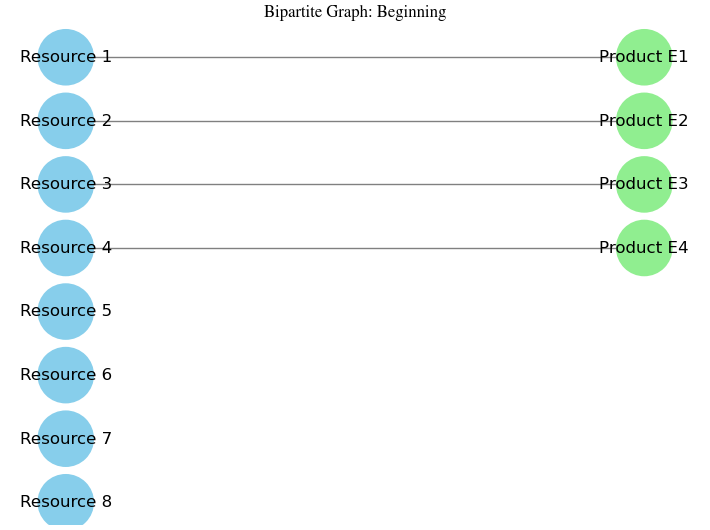

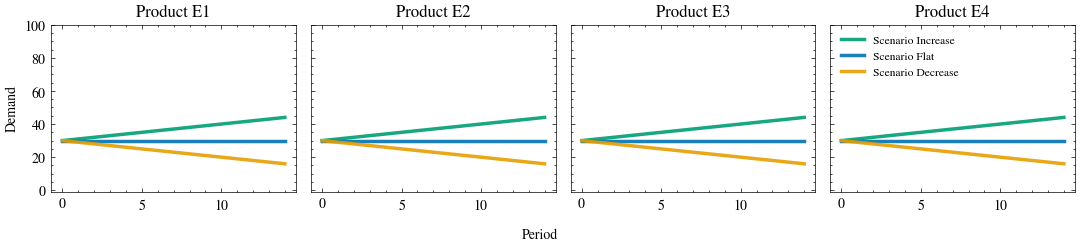

Planning scenarios: 40
Evaluation scenarios: 81
Planning probability check: 1.000000
Set parameter Username
Set parameter LicenseID to value 2764064
Set parameter LogFile to value "rosr_outputs_psi_09/case_1/gurobi.log"
Academic license - for non-commercial use only - expires 2027-01-13
Set parameter OutputFlag to value 1
Set parameter Threads to value 8
Set parameter TimeLimit to value 300
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[rosetta2] - Darwin 24.6.0 24G720)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300
Threads  8

Optimize a model with 36488 rows, 20720 columns and 120368 nonzeros (Max)
Model fingerprint: 0x08f5ce01
Model has 19380 linear objective coefficients
Variable types: 20480 continuous, 240 integer (240 binary)
Coefficient statistics:
  Matrix range     [1e+00, 4e+01]
  Objective range  [3e+00, 3e+04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 4e+01

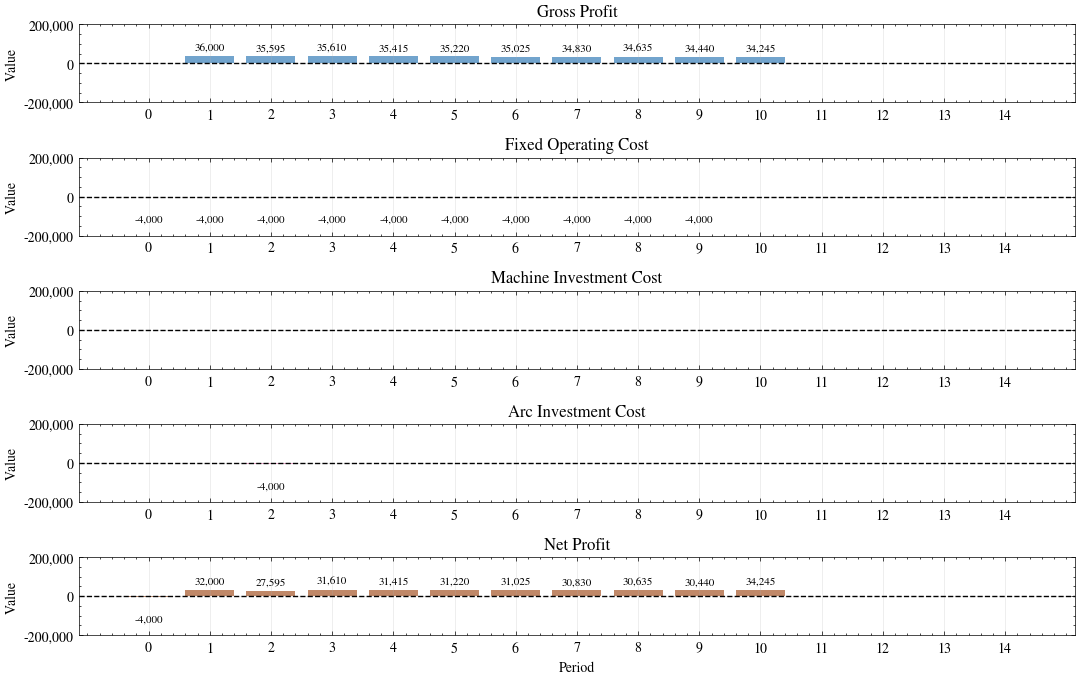

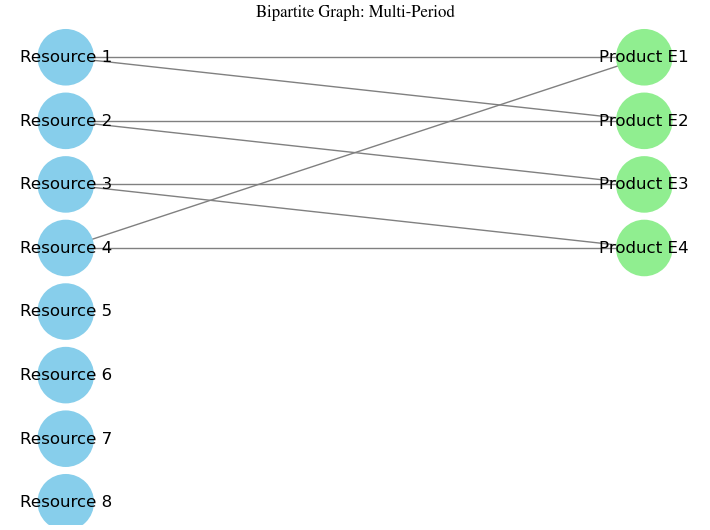

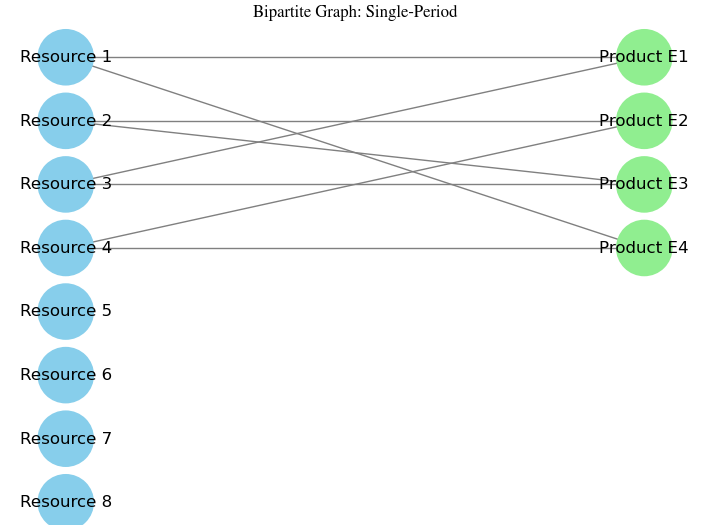

Evaluating scenario 1/81
Evaluating scenario 10/81
Evaluating scenario 20/81
Evaluating scenario 30/81
Evaluating scenario 40/81
Evaluating scenario 50/81
Evaluating scenario 60/81
Evaluating scenario 70/81
Evaluating scenario 80/81
Evaluating scenario 81/81

Policy summary statistics
                           mean      median          q1          q3  \
Multi-period         210842.803  215929.660  207881.094  215929.660   
Start-period         210483.610  215650.591  207602.024  215650.591   
Long-chain           210483.610  215650.591  207602.024  215650.591   
Decision-rule        205409.058  203553.457  200324.675  210736.691   
Perfect Information  214730.592  218720.358  210671.791  218720.359   

                            min         max       std  
Multi-period         183994.993  216189.260  7720.900  
Start-period         183456.324  215650.591  7773.082  
Long-chain           183456.324  215650.591  7773.082  
Decision-rule        187456.324  220774.612  6927.521  
Perfect

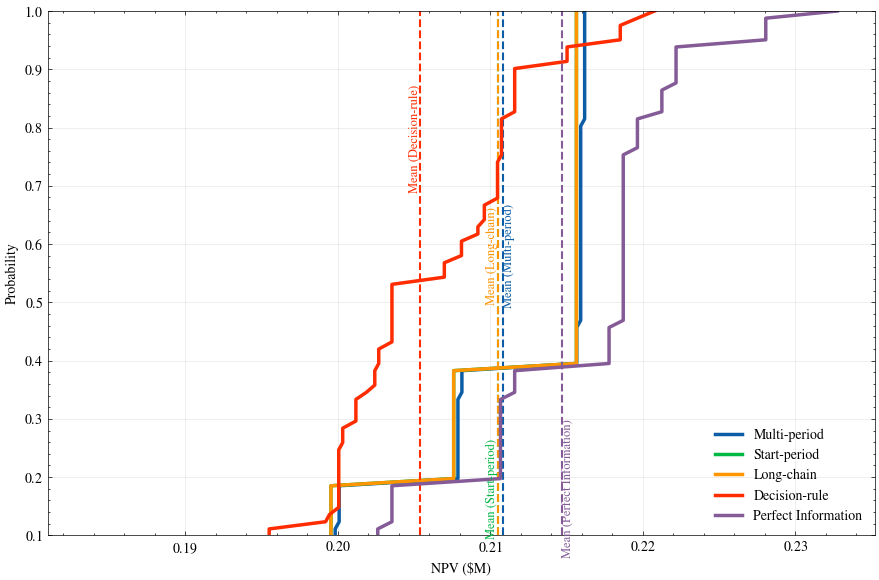

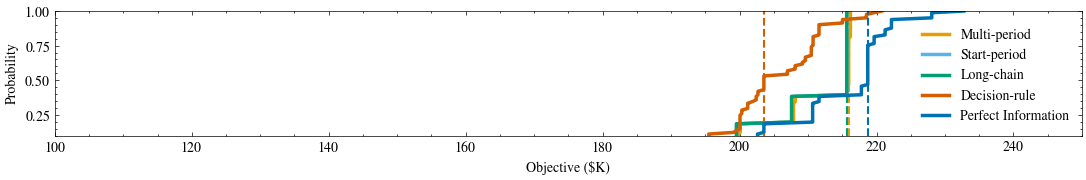

In [17]:
# Rebalancing-horizon sensitivity.
# Baseline: rebalancing_horizon=None.
# Sensitivity: psi > theta; share bounds are imposed only for t > psi.
PSI = 9

CASE_NUMBER = 1
RUN_ALL_CASES = False

# Full settings reproduce the base workflow apart from the rebalancing horizon.
RUNTIME = RuntimeConfig(rebalancing_horizon=PSI)

if __name__ == "__main__":
    if RUN_ALL_CASES:
        RESULTS = {
            case_number: run_case(
                case_number,
                runtime=RUNTIME,
                output_root=f"rosr_outputs_psi_{PSI:02d}",
            )
            for case_number in range(1, 5)
        }
    else:
        RESULTS = run_case(
            CASE_NUMBER,
            runtime=RUNTIME,
            output_root=f"rosr_outputs_psi_{PSI:02d}",
        )


### Case 2

ROSR CASE 2
Products: E=4, C=0, L=0
Base capacity: 35.0
Availability floor: 0.8
Disruption probability: 0.05
Launch probability: 0.975
Investment window θ: 4
Rebalancing horizon psi: 9
Share-bound periods: [10, 11, 12, 13, 14]


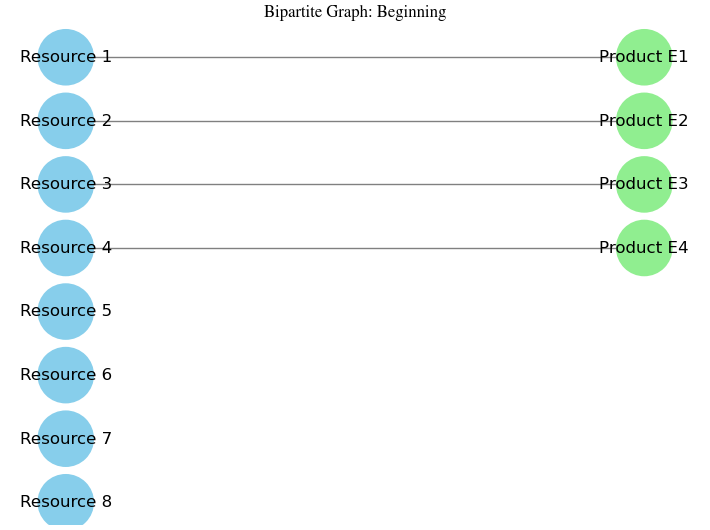

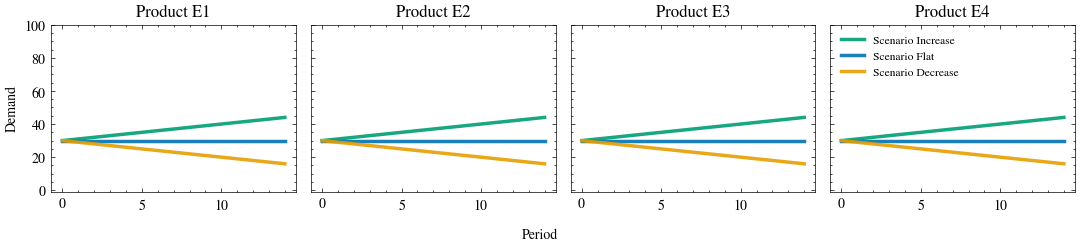

Planning scenarios: 40
Evaluation scenarios: 81
Planning probability check: 1.000000
Set parameter Username
Set parameter LicenseID to value 2764064
Set parameter LogFile to value "rosr_outputs_psi_09/case_2/gurobi.log"
Academic license - for non-commercial use only - expires 2027-01-13
Set parameter OutputFlag to value 1
Set parameter Threads to value 8
Set parameter TimeLimit to value 300
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[rosetta2] - Darwin 24.6.0 24G720)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300
Threads  8

Optimize a model with 36488 rows, 20720 columns and 118794 nonzeros (Max)
Model fingerprint: 0xb873ab57
Model has 19380 linear objective coefficients
Variable types: 20480 continuous, 240 integer (240 binary)
Coefficient statistics:
  Matrix range     [1e+00, 4e+01]
  Objective range  [3e+00, 3e+04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 4e+01

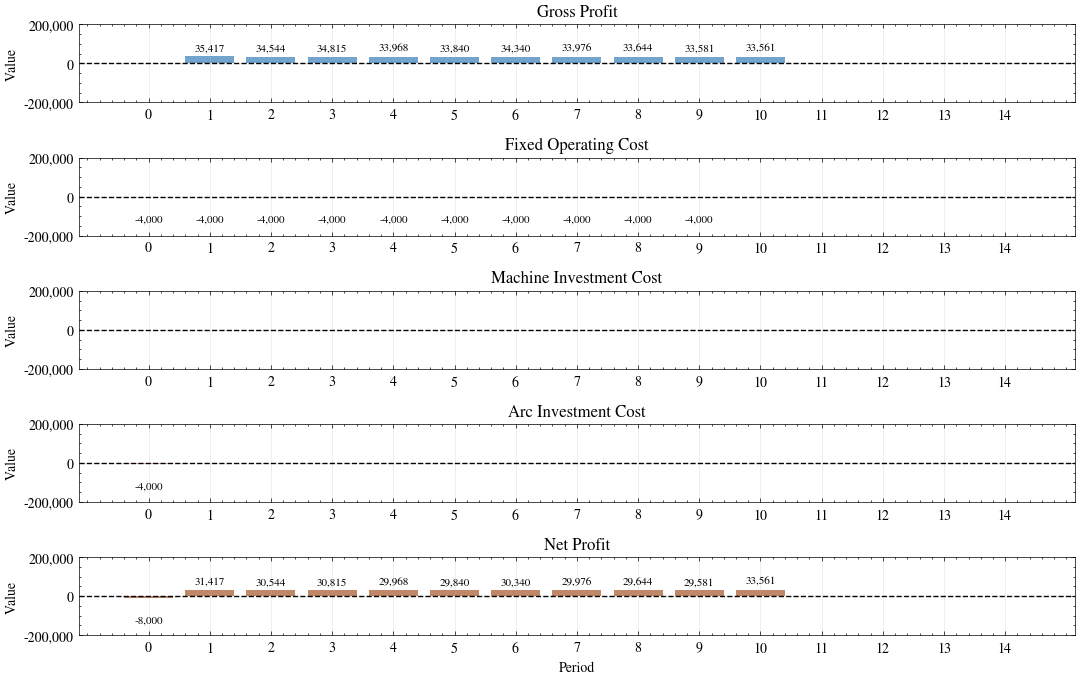

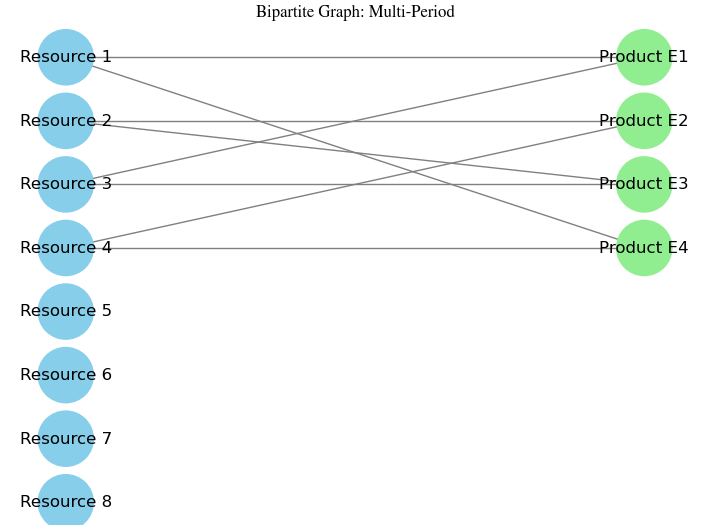

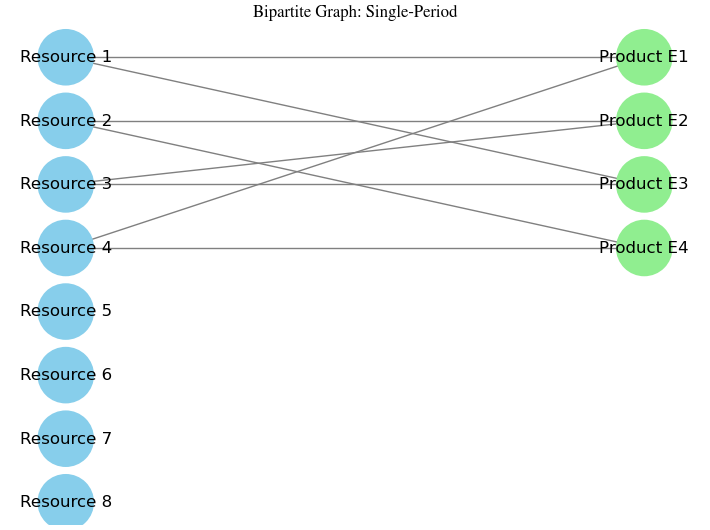

Evaluating scenario 1/81
Evaluating scenario 10/81
Evaluating scenario 20/81
Evaluating scenario 30/81
Evaluating scenario 40/81
Evaluating scenario 50/81
Evaluating scenario 60/81
Evaluating scenario 70/81
Evaluating scenario 80/81
Evaluating scenario 81/81

Policy summary statistics
                           mean      median          q1          q3  \
Multi-period         203580.838  203049.429  195714.211  214057.880   
Start-period         203580.838  203049.429  195714.211  214057.880   
Long-chain           203580.838  203049.429  195714.211  214057.880   
Decision-rule        188775.436  191526.740  176937.190  201307.911   
Perfect Information  208072.585  208878.837  200526.593  217104.354   

                            min         max        std  
Multi-period         171105.328  226516.415  12570.738  
Start-period         171105.328  226516.415  12570.738  
Long-chain           171105.328  226516.415  12570.738  
Decision-rule        130974.676  226439.915  19135.448  
Pe

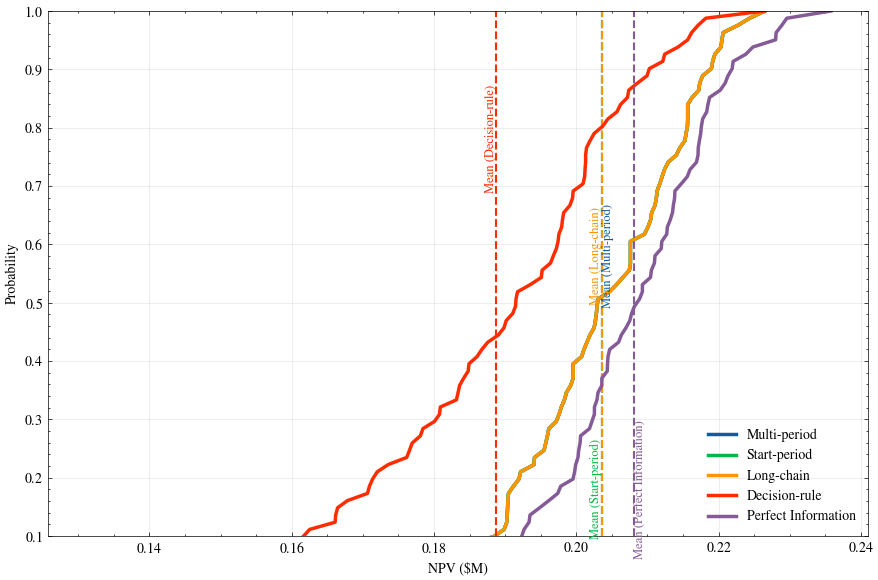

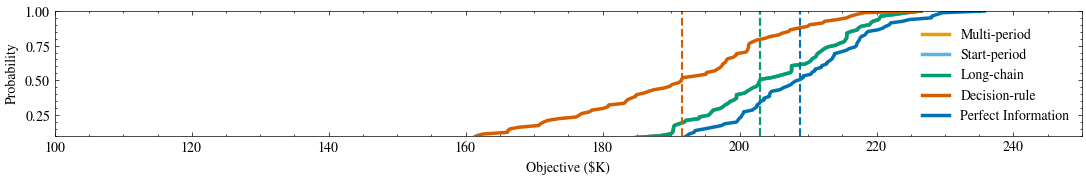

In [18]:
# Rebalancing-horizon sensitivity.
# Baseline: rebalancing_horizon=None.
# Sensitivity: psi > theta; share bounds are imposed only for t > psi.
PSI = 9

CASE_NUMBER = 2
RUN_ALL_CASES = False

# Full settings reproduce the base workflow apart from the rebalancing horizon.
RUNTIME = RuntimeConfig(rebalancing_horizon=PSI)

if __name__ == "__main__":
    if RUN_ALL_CASES:
        RESULTS = {
            case_number: run_case(
                case_number,
                runtime=RUNTIME,
                output_root=f"rosr_outputs_psi_{PSI:02d}",
            )
            for case_number in range(1, 5)
        }
    else:
        RESULTS = run_case(
            CASE_NUMBER,
            runtime=RUNTIME,
            output_root=f"rosr_outputs_psi_{PSI:02d}",
        )


### Case 3

ROSR CASE 3
Products: E=2, C=1, L=1
Base capacity: 35.0
Availability floor: 1.0
Disruption probability: 0
Launch probability: 0.975
Investment window θ: 4
Rebalancing horizon psi: 9
Share-bound periods: [10, 11, 12, 13, 14]


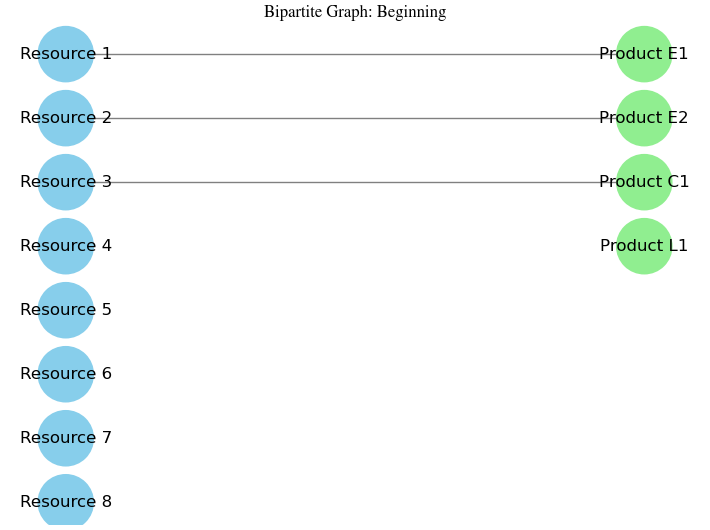

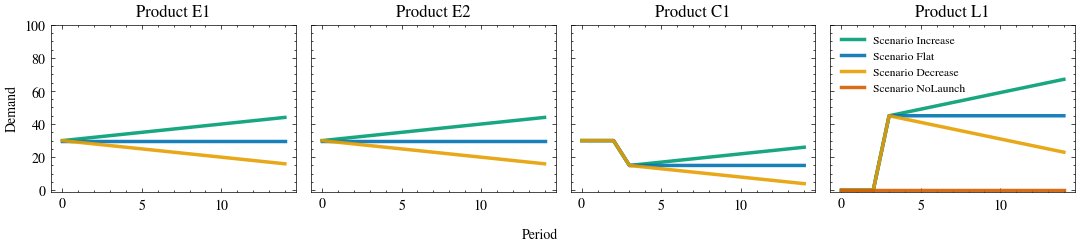

Planning scenarios: 40
Evaluation scenarios: 81
Planning probability check: 1.000000
Set parameter Username
Set parameter LicenseID to value 2764064
Set parameter LogFile to value "rosr_outputs_psi_09/case_3/gurobi.log"
Academic license - for non-commercial use only - expires 2027-01-13
Set parameter OutputFlag to value 1
Set parameter Threads to value 8
Set parameter TimeLimit to value 300
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[rosetta2] - Darwin 24.6.0 24G720)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300
Threads  8

Optimize a model with 36488 rows, 20720 columns and 120328 nonzeros (Max)
Model fingerprint: 0x26f2bfc1
Model has 19385 linear objective coefficients
Variable types: 20480 continuous, 240 integer (240 binary)
Coefficient statistics:
  Matrix range     [1e+00, 7e+01]
  Objective range  [2e-01, 3e+04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 7e+01

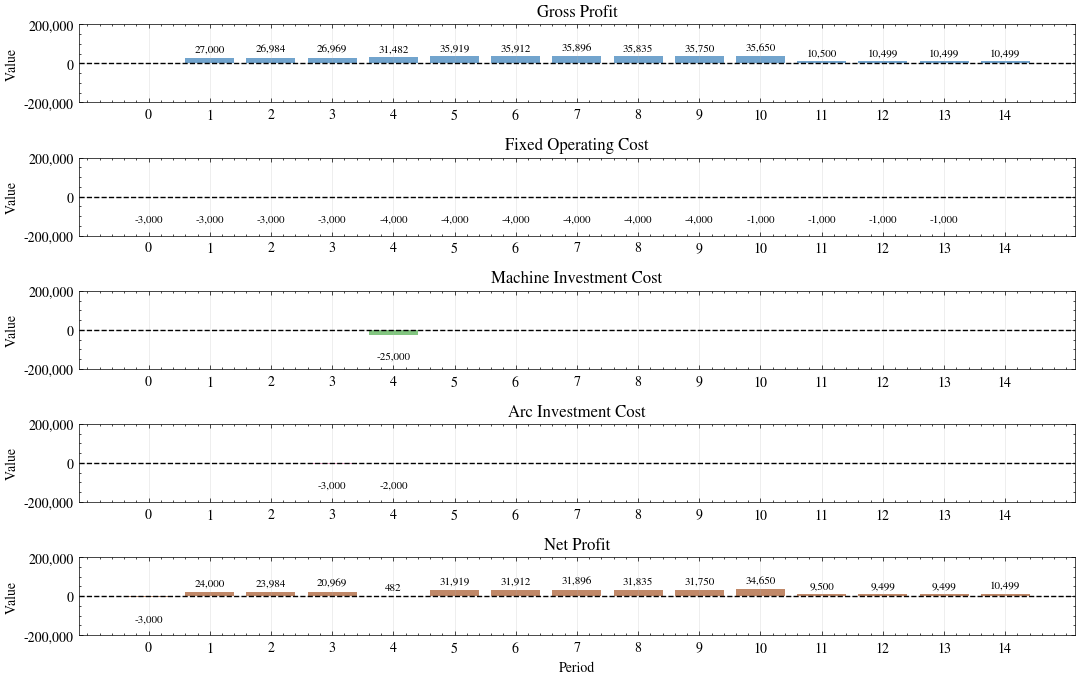

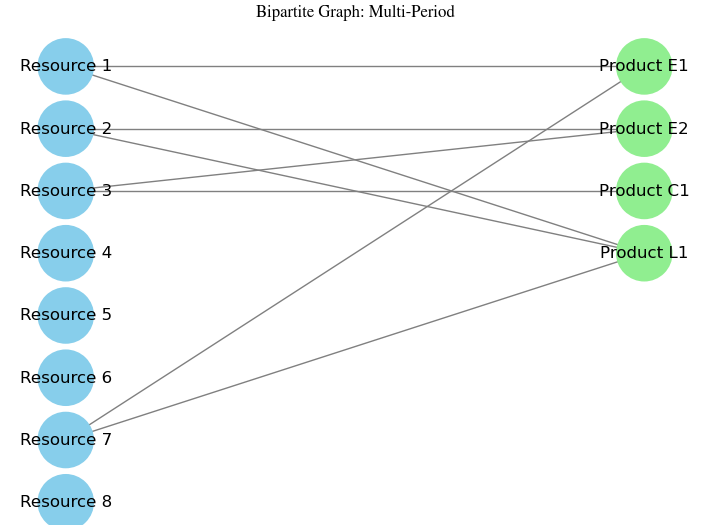

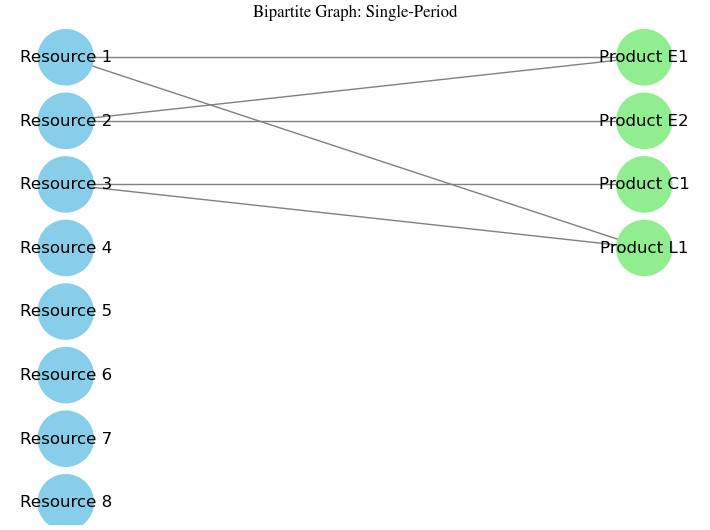

Evaluating scenario 1/81
Evaluating scenario 10/81
Evaluating scenario 20/81
Evaluating scenario 30/81
Evaluating scenario 40/81
Evaluating scenario 50/81
Evaluating scenario 60/81
Evaluating scenario 70/81
Evaluating scenario 80/81
Evaluating scenario 81/81

Policy summary statistics
                           mean      median          q1          q3  \
Multi-period         188874.287  189031.278  181656.632  196405.924   
Start-period         180517.149  180923.941  180181.365  181666.518   
Long-chain           166088.868  166245.859  158197.292  174294.426   
Decision-rule        178964.001  179584.495  173446.559  185105.580   
Perfect Information  190383.682  189780.079  182405.432  197154.725   

                            min         max        std  
Multi-period         163875.613  208946.696  10374.714  
Start-period         170748.802  182409.094   1862.555  
Long-chain           139742.353  187509.118  11013.318  
Decision-rule        158170.717  193001.738   7719.251  
Pe

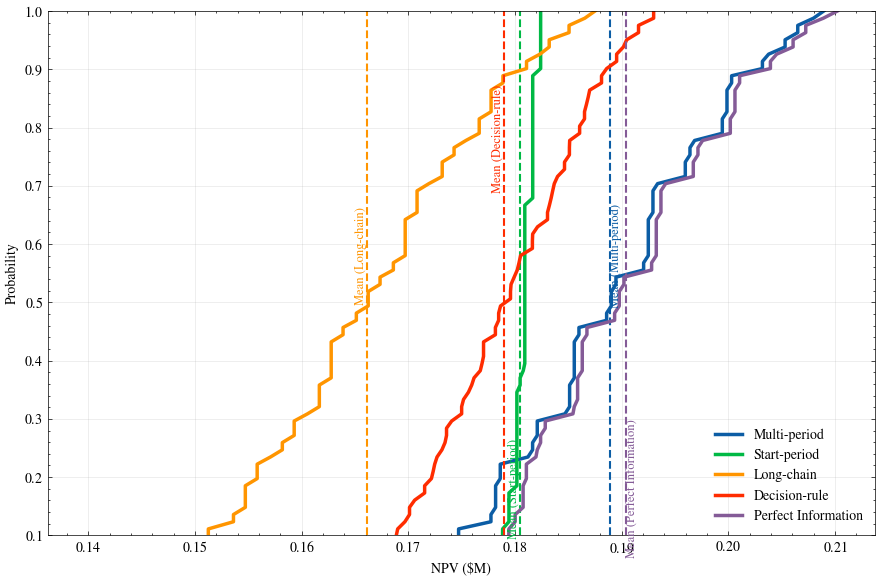

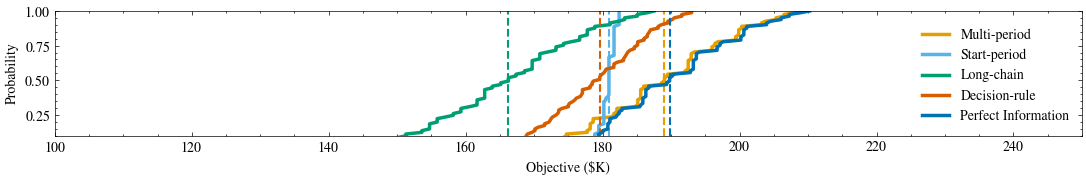

In [19]:
# Rebalancing-horizon sensitivity.
# Baseline: rebalancing_horizon=None.
# Sensitivity: psi > theta; share bounds are imposed only for t > psi.
PSI = 9

CASE_NUMBER = 3
RUN_ALL_CASES = False

# Full settings reproduce the base workflow apart from the rebalancing horizon.
RUNTIME = RuntimeConfig(rebalancing_horizon=PSI)

if __name__ == "__main__":
    if RUN_ALL_CASES:
        RESULTS = {
            case_number: run_case(
                case_number,
                runtime=RUNTIME,
                output_root=f"rosr_outputs_psi_{PSI:02d}",
            )
            for case_number in range(1, 5)
        }
    else:
        RESULTS = run_case(
            CASE_NUMBER,
            runtime=RUNTIME,
            output_root=f"rosr_outputs_psi_{PSI:02d}",
        )


### Case 4

ROSR CASE 4
Products: E=2, C=1, L=1
Base capacity: 35.0
Availability floor: 0.8
Disruption probability: 0.05
Launch probability: 0.975
Investment window θ: 4
Rebalancing horizon psi: 9
Share-bound periods: [10, 11, 12, 13, 14]


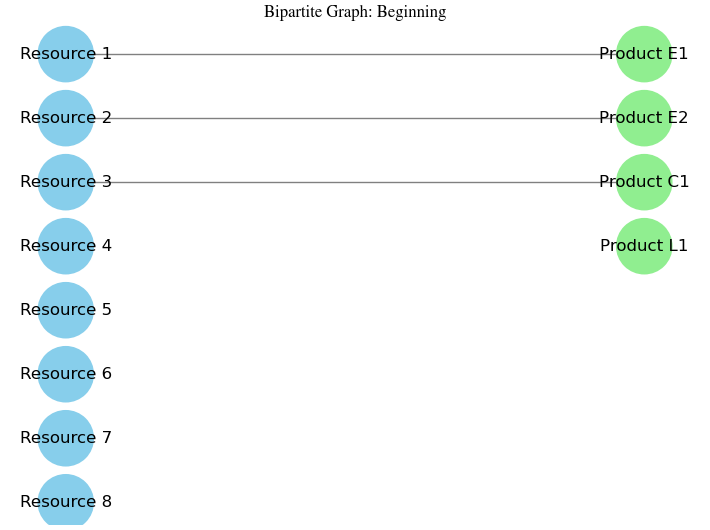

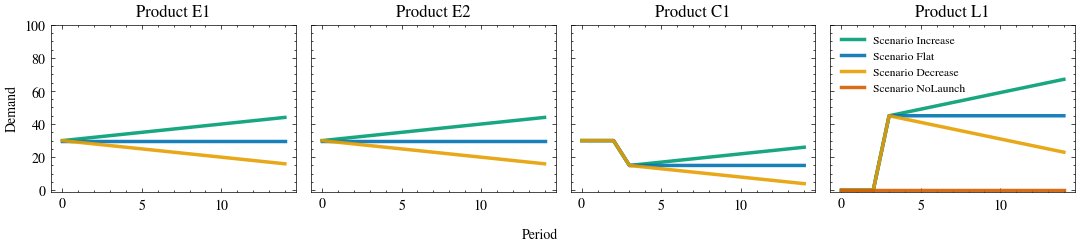

Planning scenarios: 40
Evaluation scenarios: 81
Planning probability check: 1.000000
Set parameter Username
Set parameter LicenseID to value 2764064
Set parameter LogFile to value "rosr_outputs_psi_09/case_4/gurobi.log"
Academic license - for non-commercial use only - expires 2027-01-13
Set parameter OutputFlag to value 1
Set parameter Threads to value 8
Set parameter TimeLimit to value 300
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[rosetta2] - Darwin 24.6.0 24G720)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300
Threads  8

Optimize a model with 36488 rows, 20720 columns and 118754 nonzeros (Max)
Model fingerprint: 0x1b131cdd
Model has 19385 linear objective coefficients
Variable types: 20480 continuous, 240 integer (240 binary)
Coefficient statistics:
  Matrix range     [1e+00, 7e+01]
  Objective range  [2e-01, 3e+04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 7e+01

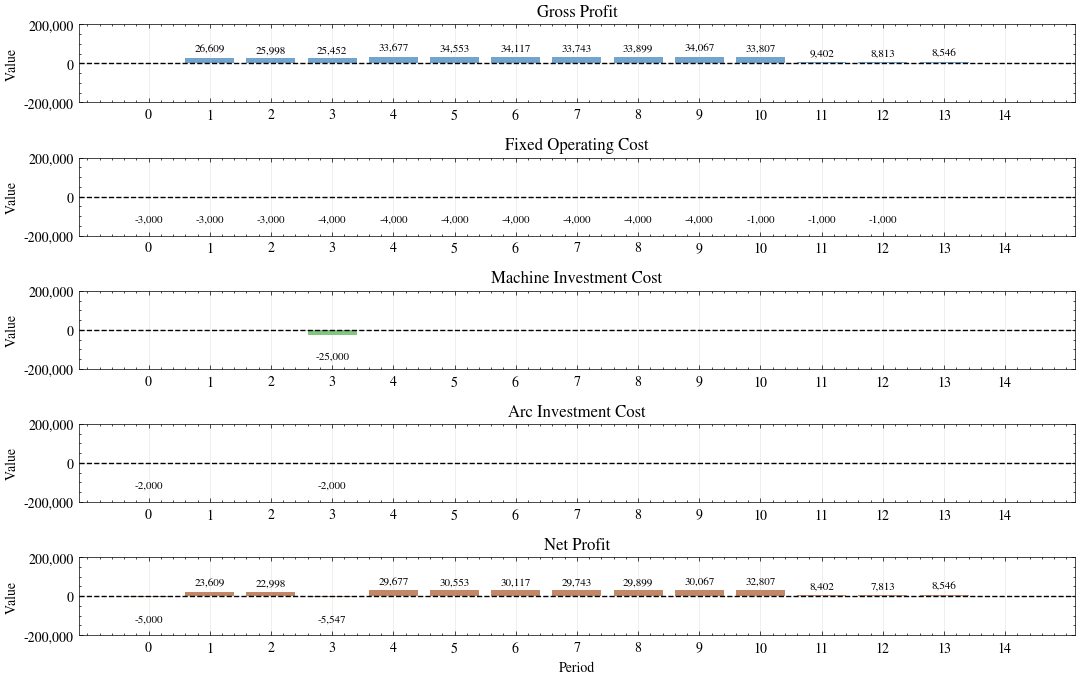

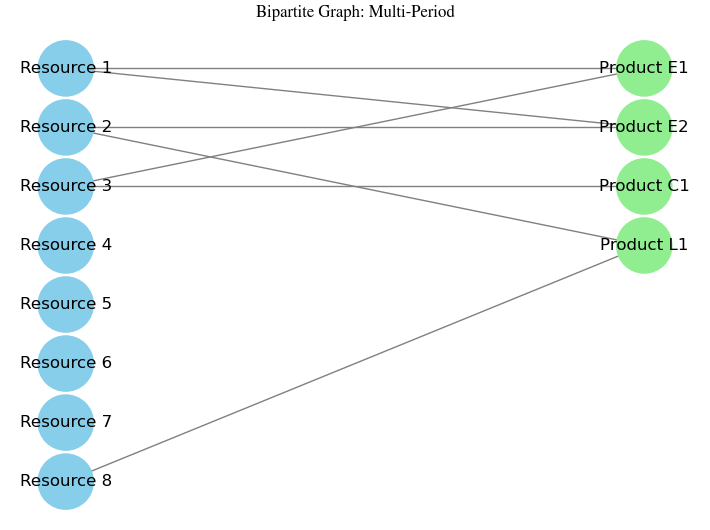

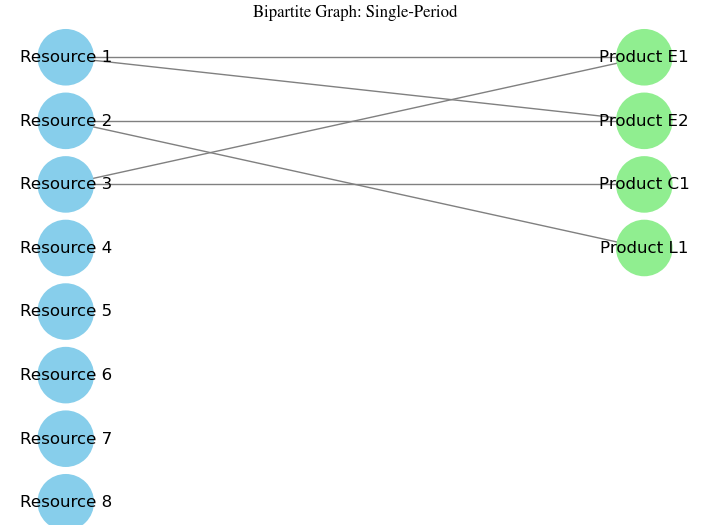

Evaluating scenario 1/81
Evaluating scenario 10/81
Evaluating scenario 20/81
Evaluating scenario 30/81
Evaluating scenario 40/81
Evaluating scenario 50/81
Evaluating scenario 60/81
Evaluating scenario 70/81
Evaluating scenario 80/81
Evaluating scenario 81/81

Policy summary statistics
                           mean      median          q1          q3  \
Multi-period         174012.659  176059.436  165783.775  184028.597   
Start-period         158353.375  160744.969  152563.721  165598.590   
Long-chain           157195.350  158197.292  149136.985  165417.064   
Decision-rule        150276.972  155558.559  136189.575  168844.447   
Perfect Information  179268.570  179468.655  172423.815  187377.582   

                            min         max        std  
Multi-period         142346.354  192846.729  11472.638  
Start-period         130993.634  169516.065   8984.317  
Long-chain           132666.831  174901.318  10340.304  
Decision-rule         87346.084  185781.401  23851.565  
Pe

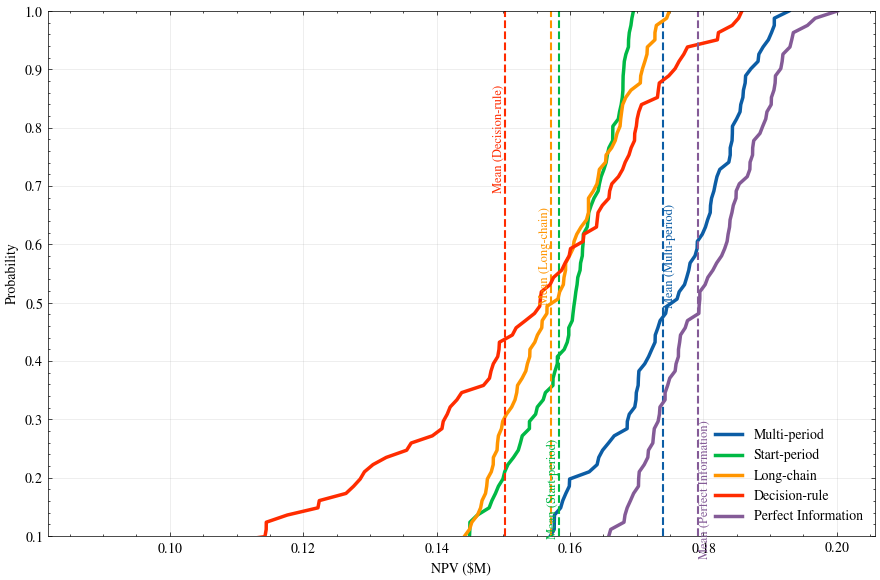

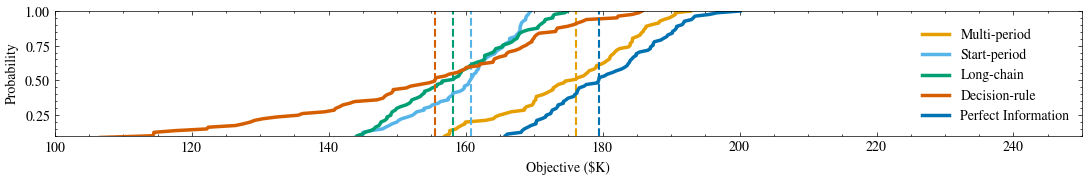

In [20]:
# Rebalancing-horizon sensitivity.
# Baseline: rebalancing_horizon=None.
# Sensitivity: psi > theta; share bounds are imposed only for t > psi.
PSI = 9

CASE_NUMBER = 4
RUN_ALL_CASES = False

# Full settings reproduce the base workflow apart from the rebalancing horizon.
RUNTIME = RuntimeConfig(rebalancing_horizon=PSI)

if __name__ == "__main__":
    if RUN_ALL_CASES:
        RESULTS = {
            case_number: run_case(
                case_number,
                runtime=RUNTIME,
                output_root=f"rosr_outputs_psi_{PSI:02d}",
            )
            for case_number in range(1, 5)
        }
    else:
        RESULTS = run_case(
            CASE_NUMBER,
            runtime=RUNTIME,
            output_root=f"rosr_outputs_psi_{PSI:02d}",
        )
